In [29]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'pihps_food_inflation_indonesia.csv'

print('Project root:', PROJECT_ROOT)
print('Dataset path :', DATA_PATH)

Project root: C:\Users\caran\Desktop\WORK\Projects\Misc\Mercatorie
Dataset path : C:\Users\caran\Desktop\WORK\Projects\Misc\Mercatorie\data\raw\pihps_food_inflation_indonesia.csv


# Core libraries
- **pandas, numpy** for data handling
- **matplotlib, seaborn** for exploration
- **scikit-learn** for preprocessing, pipelines, training, and evaluation
- **xgboost** for a strong tabular-data baseline
- **joblib** for saving trained artifacts
- **streamlit** for dashboarding stuff

In [109]:
from pathlib import Path

import numpy as np
import pandas as pd

# evaluation & visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# preprocessing-related
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# model-related
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)

import joblib
import streamlit as st

print('Imports loaded successfully.')

Imports loaded successfully.


# Load Dataset

In [43]:
# load data
df = pd.read_csv(DATA_PATH)

# dataset overview
print("Shape:", df.shape)
display(df.head())

# column names
print("Columns:")
for col in df.columns:
    print("-", col)

# data types
display(df.dtypes.to_frame("dtype"))

# date coverage
df["date"] = pd.to_datetime(df["date"])
print("Date range             :", df["date"].min(), "to", df["date"].max())

# unique commodities
print("Number of commodities  :", df["commodity"].nunique())
print("Commodity list         :", sorted(df["commodity"].unique()))

# variable groups by type
categorical_cols = ["commodity"]
binary_or_flag_cols = ["is_observed_source", "is_month_start", "is_month_end"]
time_cols = ["date", "year", "month", "quarter", "day_of_week", "week_of_year"]
target_cols = ["target_7d_inflation_pct", "target_30d_inflation_pct"]

numeric_feature_cols = [
    col for col in df.columns
    if col not in categorical_cols + binary_or_flag_cols + time_cols + target_cols
]

print("\nCategorical columns     :", categorical_cols)
print("Binary/flag columns     :", binary_or_flag_cols)
print("Time columns            :", time_cols)
print("Target columns          :", target_cols)
print("Numeric feature columns :", numeric_feature_cols)

print("\nCounts")
print("Total columns      :", len(df.columns))
print("Categorical        :", len(categorical_cols))
print("Binary/flag        :", len(binary_or_flag_cols))
print("Time-related       :", len(time_cols))
print("Targets            :", len(target_cols))
print("Numeric features   :", len(numeric_feature_cols))

# target distributions
display(df[target_cols].describe().T)

# primary & secondary modeling target for this project
primary_target = "target_7d_inflation_pct"
secondary_target = "target_30d_inflation_pct"
print("\nPrimary target selected for modeling   :", primary_target)
print("\nSecondary target selected for modeling :", secondary_target)

Shape: (12320, 25)


,date,commodity,commodity_code,is_observed_source,price_idr,year,month,quarter,day_of_week,week_of_year,is_month_start,is_month_end,price_lag_1d,price_lag_7d,price_lag_30d,price_change_1d_pct,price_change_7d_pct,price_change_30d_pct,rolling_mean_7d,rolling_mean_30d,rolling_std_30d,price_vs_ma30_pct,volatility_30d_pct,target_7d_inflation_pct,target_30d_inflation_pct
0,2018-01-31,beras,1,1,12100.0,2018,1,1,2,5,0,1,12100.0,12100.0,11050.0,0.0,0.0,9.5023,12100.0,11965.0000,127.4078,1.1283,1.1522,0.0,-0.8264
1,2018-02-01,beras,1,1,12100.0,2018,2,1,3,5,1,0,12100.0,12100.0,11750.0,0.0,0.0,2.9787,12100.0,11976.6667,122.9896,1.0298,0.1808,0.0,-0.8264
2,2018-02-02,beras,1,1,12100.0,2018,2,1,4,5,0,0,12100.0,12100.0,11750.0,0.0,0.0,2.9787,12100.0,11988.3333,117.2114,0.9315,0.1808,0.0,-0.8264
3,2018-02-03,beras,1,0,12100.0,2018,2,1,5,5,0,0,12100.0,12100.0,11750.0,0.0,0.0,2.9787,12100.0,12000.0000,109.8588,0.8333,0.1808,0.0,-0.8264
4,2018-02-04,beras,1,0,12100.0,2018,2,1,6,5,0,0,12100.0,12100.0,11800.0,0.0,0.0,2.5424,12100.0,12010.0000,104.5516,0.7494,0.1706,0.0,-1.2397


Columns:
- date
- commodity
- commodity_code
- is_observed_source
- price_idr
- year
- month
- quarter
- day_of_week
- week_of_year
- is_month_start
- is_month_end
- price_lag_1d
- price_lag_7d
- price_lag_30d
- price_change_1d_pct
- price_change_7d_pct
- price_change_30d_pct
- rolling_mean_7d
- rolling_mean_30d
- rolling_std_30d
- price_vs_ma30_pct
- volatility_30d_pct
- target_7d_inflation_pct
- target_30d_inflation_pct


,dtype
date,object
commodity,object
commodity_code,int64
is_observed_source,int64
price_idr,float64
year,int64
month,int64
quarter,int64
day_of_week,int64
week_of_year,int64


Date range             : 2018-01-31 00:00:00 to 2024-10-29 00:00:00
Number of commodities  : 5
Commodity list         : ['bawang_merah', 'beras', 'cabai_merah', 'minyak_goreng', 'telur_ayam']

Categorical columns     : ['commodity']
Binary/flag columns     : ['is_observed_source', 'is_month_start', 'is_month_end']
Time columns            : ['date', 'year', 'month', 'quarter', 'day_of_week', 'week_of_year']
Target columns          : ['target_7d_inflation_pct', 'target_30d_inflation_pct']
Numeric feature columns : ['commodity_code', 'price_idr', 'price_lag_1d', 'price_lag_7d', 'price_lag_30d', 'price_change_1d_pct', 'price_change_7d_pct', 'price_change_30d_pct', 'rolling_mean_7d', 'rolling_mean_30d', 'rolling_std_30d', 'price_vs_ma30_pct', 'volatility_30d_pct']

Counts
Total columns      : 25
Categorical        : 1
Binary/flag        : 3
Time-related       : 6
Targets            : 2
Numeric features   : 13


,count,mean,std,min,25%,50%,75%,max
target_7d_inflation_pct,12320.0,0.250980,6.558166,-51.5306,-0.900900,0.0,0.9524,115.0000
target_30d_inflation_pct,12320.0,0.914218,11.794271,-60.9455,-2.632675,0.0,3.2198,167.3684



Primary target selected for modeling   : target_7d_inflation_pct

Secondary target selected for modeling : target_30d_inflation_pct


# Exploratory Data Analysis

In [32]:
print("Primary target   :", primary_target)
print("Secondary target :", secondary_target)

Primary target   : target_7d_inflation_pct
Secondary target : target_30d_inflation_pct


Missing Value Analysis

,missing_count,missing_pct
date,0,0.0
commodity,0,0.0
commodity_code,0,0.0
is_observed_source,0,0.0
price_idr,0,0.0
year,0,0.0
month,0,0.0
quarter,0,0.0
day_of_week,0,0.0
week_of_year,0,0.0


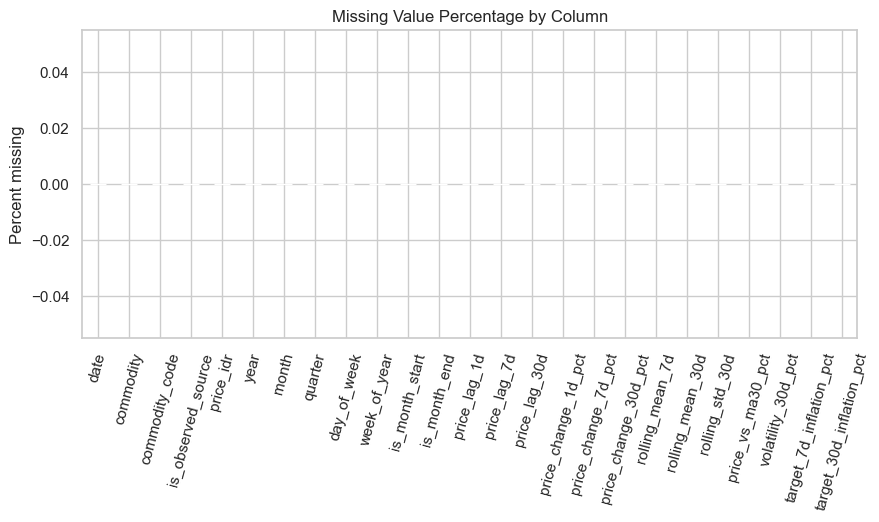

In [33]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

display(missing_summary)

plt.figure(figsize=(10, 4))
missing_summary["missing_pct"].plot(kind="bar")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Percent missing")
plt.xticks(rotation=75)
plt.show()

Numerical Features Summaries

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
commodity_code,12320.0,3.000000,1.414271,1.0000,2.000000,3.00000,4.000000,5.0000
is_observed_source,12320.0,0.707386,0.454981,0.0000,0.000000,1.00000,1.000000,1.0000
price_idr,12320.0,27203.628247,13454.708784,9600.0000,14300.000000,25850.00000,35312.500000,89050.0000
year,12320.0,2020.960633,1.952141,2018.0000,2019.000000,2021.00000,2023.000000,2024.0000
month,12320.0,6.463474,3.367204,1.0000,4.000000,6.00000,9.000000,12.0000
quarter,12320.0,2.488636,1.100089,1.0000,2.000000,2.00000,3.000000,4.0000
day_of_week,12320.0,3.000000,2.000081,0.0000,1.000000,3.00000,5.000000,6.0000
week_of_year,12320.0,26.329951,14.705000,1.0000,14.000000,26.00000,39.000000,53.0000
is_month_start,12320.0,0.032873,0.178312,0.0000,0.000000,0.00000,0.000000,1.0000
is_month_end,12320.0,0.032873,0.178312,0.0000,0.000000,0.00000,0.000000,1.0000


Key Features Distribution

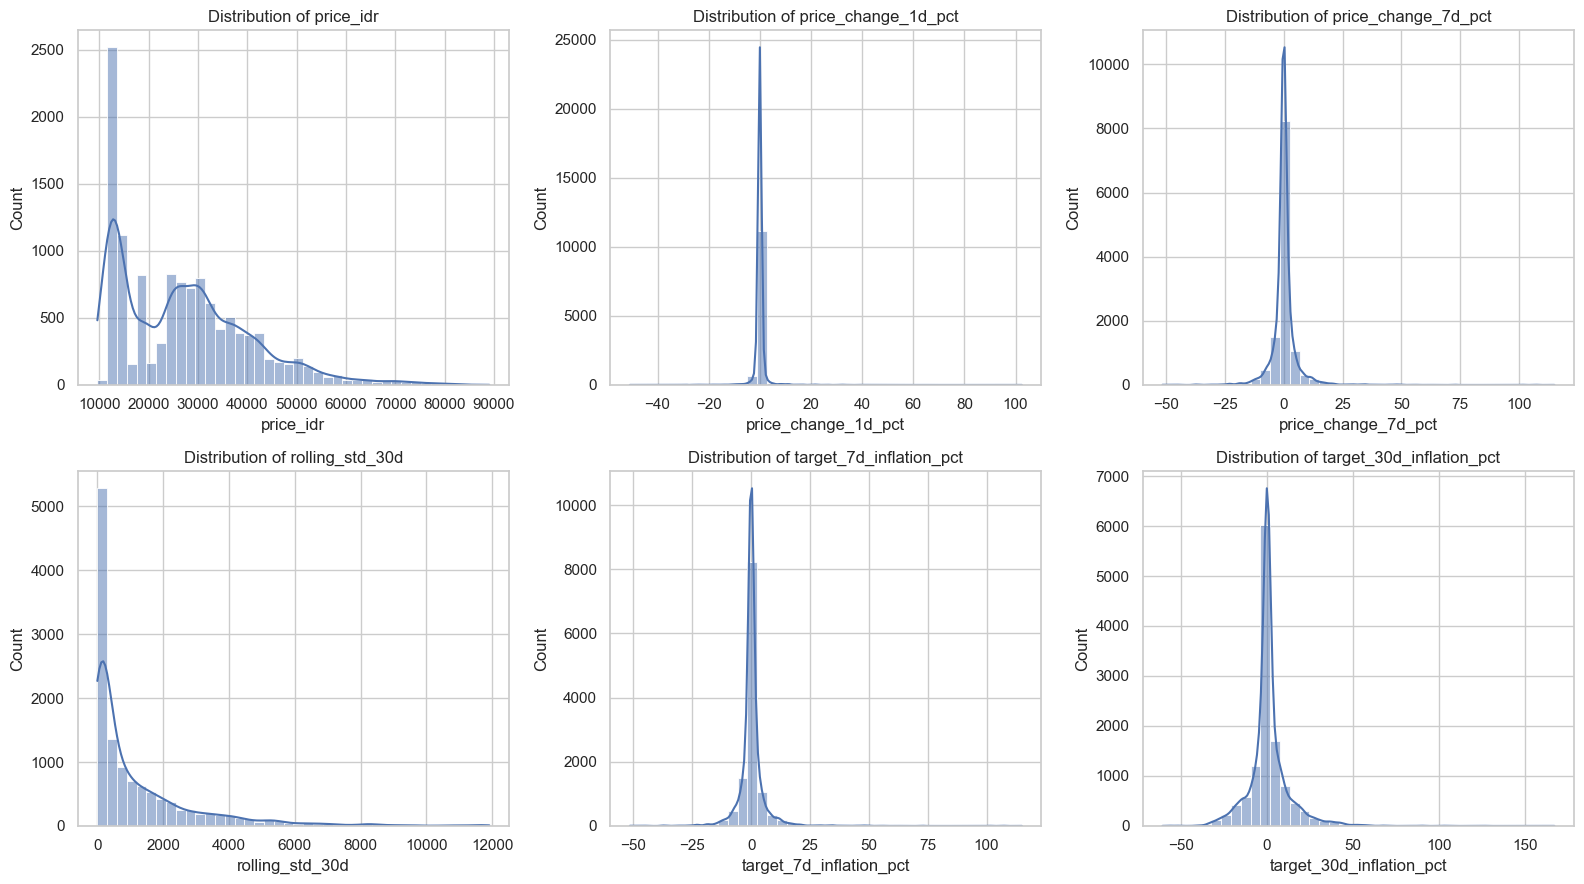

In [35]:
plot_cols = [
    "price_idr",
    "price_change_1d_pct",
    "price_change_7d_pct",
    "rolling_std_30d",
    primary_target,
    secondary_target
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Outliers by Commodity Type

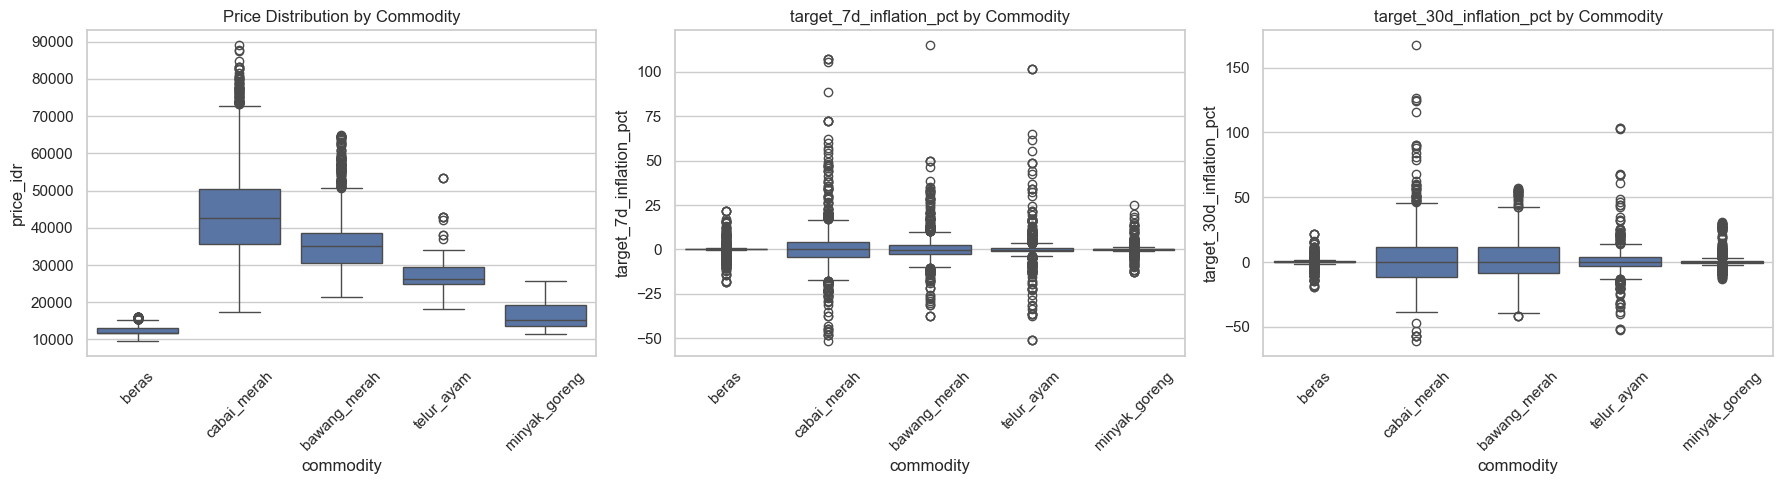

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="commodity", y="price_idr", ax=axes[0])
axes[0].set_title("Price Distribution by Commodity")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="commodity", y=primary_target, ax=axes[1])
axes[1].set_title(f"{primary_target} by Commodity")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="commodity", y=secondary_target, ax=axes[2])
axes[2].set_title(f"{secondary_target} by Commodity")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Correlation Analysis

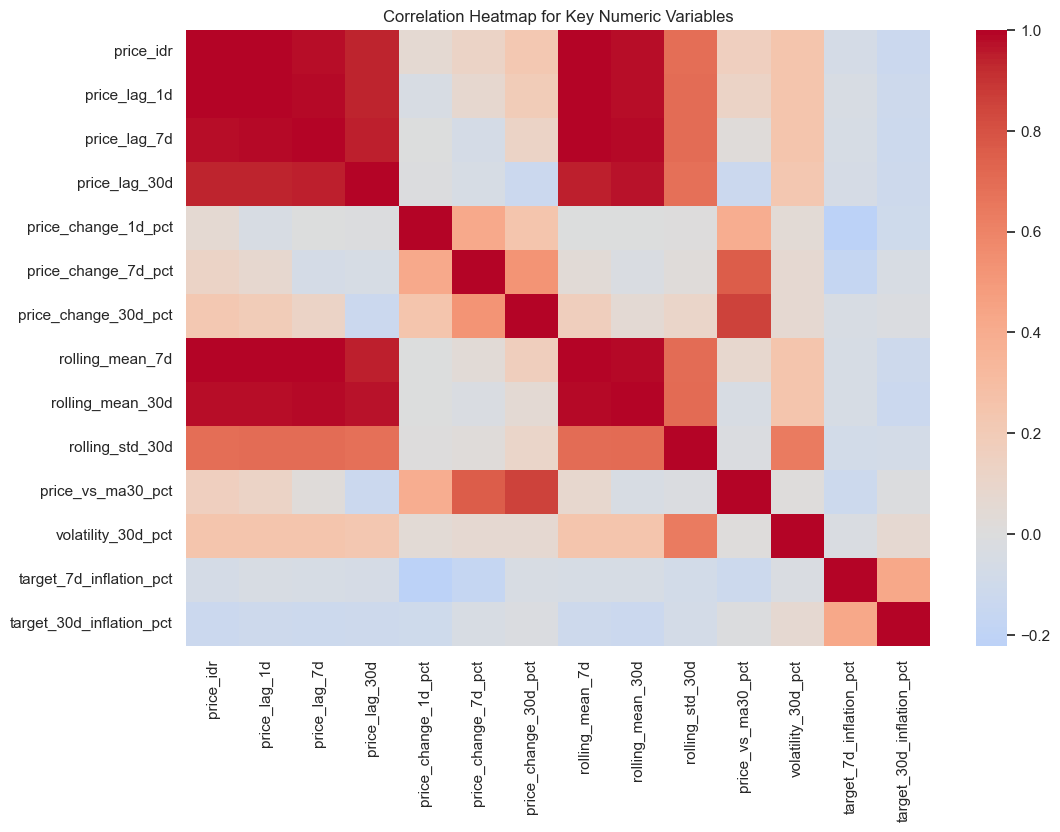

Correlation with primary target:


,corr_with_7d
target_7d_inflation_pct,1.000000
target_30d_inflation_pct,0.428810
volatility_30d_pct,-0.022778
price_change_30d_pct,-0.038237
price_lag_1d,-0.045358
rolling_mean_7d,-0.046759
price_lag_7d,-0.046854
rolling_mean_30d,-0.050469
price_lag_30d,-0.060095
price_idr,-0.065759


Correlation with secondary target:


,corr_with_30d
target_30d_inflation_pct,1.000000
target_7d_inflation_pct,0.428810
volatility_30d_pct,0.065867
price_vs_ma30_pct,-0.009758
price_change_30d_pct,-0.016172
price_change_7d_pct,-0.037849
rolling_std_30d,-0.071516
price_change_1d_pct,-0.107275
price_lag_1d,-0.113180
price_lag_30d,-0.115208


In [37]:
corr_cols = [
    "price_idr",
    "price_lag_1d",
    "price_lag_7d",
    "price_lag_30d",
    "price_change_1d_pct",
    "price_change_7d_pct",
    "price_change_30d_pct",
    "rolling_mean_7d",
    "rolling_mean_30d",
    "rolling_std_30d",
    "price_vs_ma30_pct",
    "volatility_30d_pct",
    primary_target,
    secondary_target
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Key Numeric Variables")
plt.show()

corr_to_primary = corr_matrix[primary_target].sort_values(ascending=False)
corr_to_secondary = corr_matrix[secondary_target].sort_values(ascending=False)

print("Correlation with primary target:")
display(corr_to_primary.to_frame("corr_with_7d"))

print("Correlation with secondary target:")
display(corr_to_secondary.to_frame("corr_with_30d"))

Commodity Trend Exploration

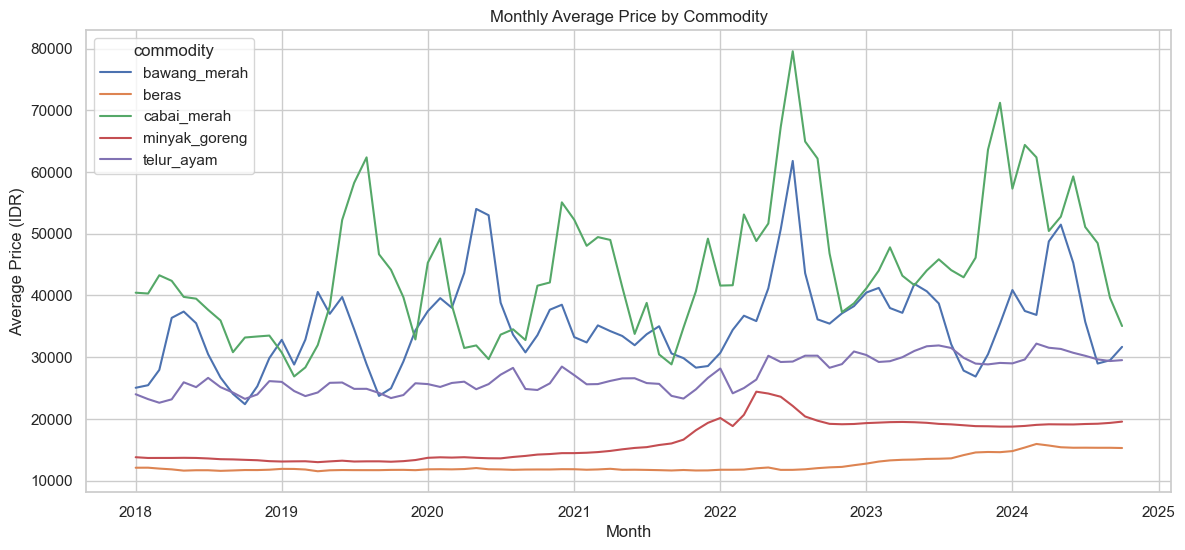

In [38]:
monthly_prices = (
    df.assign(year_month=df["date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["year_month", "commodity"], as_index=False)["price_idr"]
      .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_prices, x="year_month", y="price_idr", hue="commodity")
plt.title("Monthly Average Price by Commodity")
plt.xlabel("Month")
plt.ylabel("Average Price (IDR)")
plt.show()

Inflation Pattern Exploration

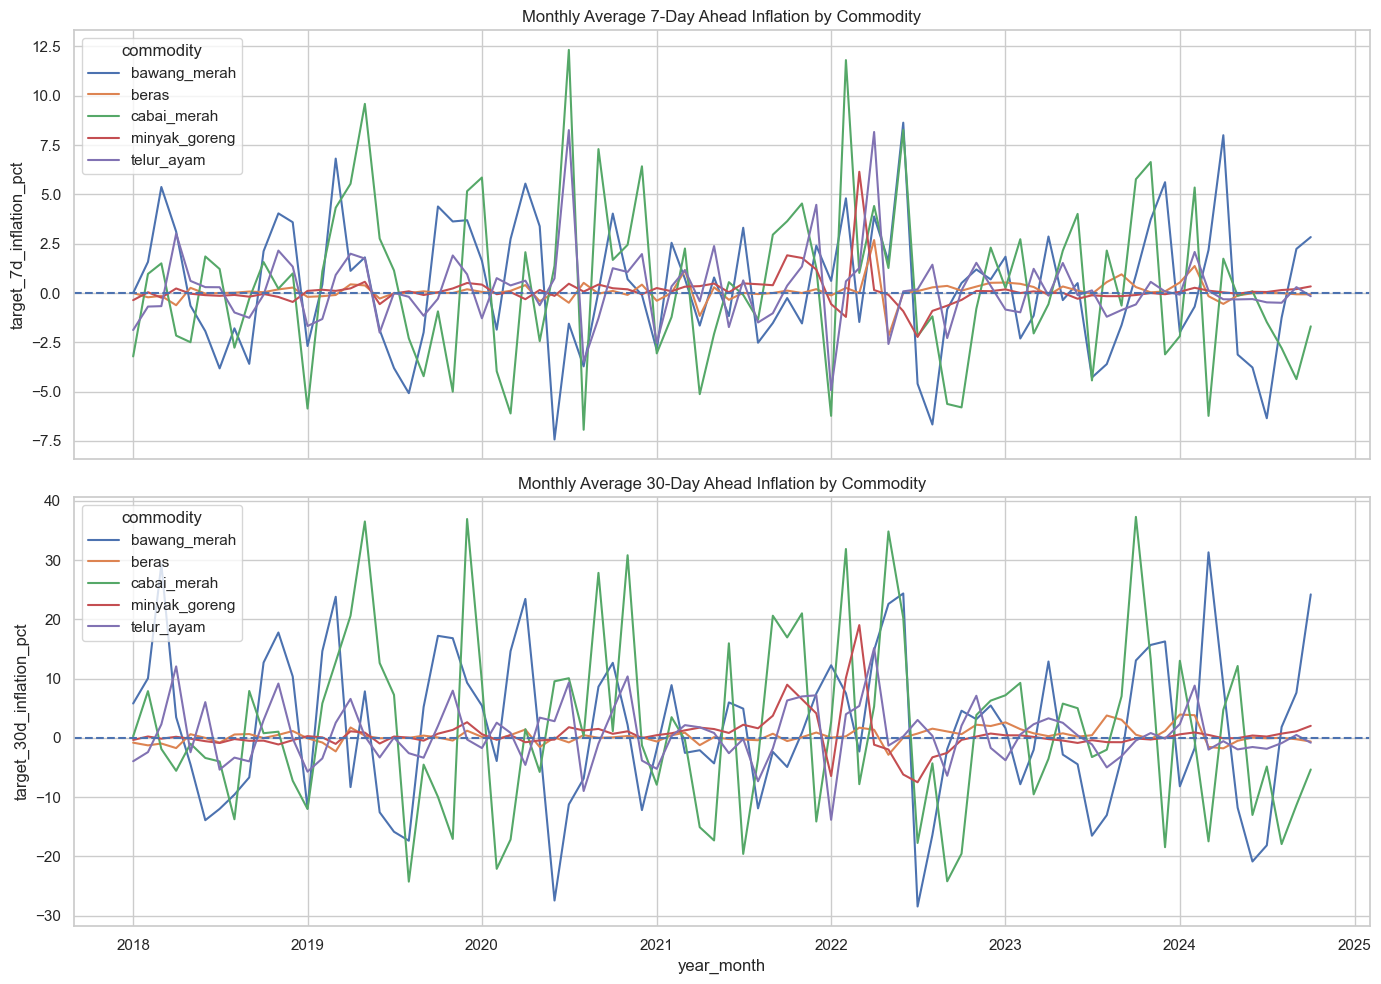

In [39]:
monthly_targets = (
    df.assign(year_month=df["date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["year_month", "commodity"], as_index=False)[[primary_target, secondary_target]]
      .mean()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(
    data=monthly_targets,
    x="year_month",
    y=primary_target,
    hue="commodity",
    ax=axes[0]
)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Monthly Average 7-Day Ahead Inflation by Commodity")

sns.lineplot(
    data=monthly_targets,
    x="year_month",
    y=secondary_target,
    hue="commodity",
    ax=axes[1]
)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Monthly Average 30-Day Ahead Inflation by Commodity")

plt.tight_layout()
plt.show()

Class Balance Check

In [40]:
def make_inflation_class(x, stable_band=1.0):
    if x > stable_band:
        return "Inflation"
    elif x < -stable_band:
        return "Deflation"
    return "Stable"

df["class_7d_preview"] = df[primary_target].apply(make_inflation_class)
df["class_30d_preview"] = df[secondary_target].apply(make_inflation_class)

print("Preview class distribution for 7-day target:")
display(df["class_7d_preview"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))

print("Preview class distribution for 30-day target:")
display(df["class_30d_preview"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))

Preview class distribution for 7-day target:


,percent
class_7d_preview,
Stable,51.37
Inflation,24.54
Deflation,24.09


Preview class distribution for 30-day target:


,percent
class_30d_preview,
Inflation,35.71
Stable,32.72
Deflation,31.57


Commodity-Level Volatility Summary

In [41]:
commodity_summary = (
    df.groupby("commodity")
      .agg(
          avg_price=("price_idr", "mean"),
          std_price=("price_idr", "std"),
          avg_7d_target=(primary_target, "mean"),
          std_7d_target=(primary_target, "std"),
          avg_30d_target=(secondary_target, "mean"),
          std_30d_target=(secondary_target, "std")
      )
      .sort_values("std_30d_target", ascending=False)
)

display(commodity_summary)

,avg_price,std_price,avg_7d_target,std_7d_target,avg_30d_target,std_30d_target
commodity,,,,,,
cabai_merah,44405.864448,11589.029294,0.505624,11.044092,1.510136,19.456704
bawang_merah,35486.728896,7509.772927,0.293279,6.556567,1.631252,15.064857
telur_ayam,27083.096591,2971.266066,0.245489,6.447868,0.590913,8.210119
minyak_goreng,16503.226461,3137.254169,0.119929,1.864489,0.530688,3.904667
beras,12539.224838,1304.039979,0.090579,2.235190,0.308102,2.468894


# Feature Engineering

In [44]:
# clean, ordered copy
df_fe = df.copy().sort_values(["commodity", "date"]).reset_index(drop=True)

# 1. cyclical calendar features
# raw month values treat January (1) & December (12) as far apart, and this fixes that
df_fe["month_sin"] = np.sin(2 * np.pi * df_fe["month"] / 12)
df_fe["month_cos"] = np.cos(2 * np.pi * df_fe["month"] / 12)

df_fe["week_sin"] = np.sin(2 * np.pi * df_fe["week_of_year"] / 52)
df_fe["week_cos"] = np.cos(2 * np.pi * df_fe["week_of_year"] / 52)

df_fe["dow_sin"] = np.sin(2 * np.pi * df_fe["day_of_week"] / 7)
df_fe["dow_cos"] = np.cos(2 * np.pi * df_fe["day_of_week"] / 7)

# 2. price deviation / abnormality / trend features
# determines how far is the current price from its recent normal, measured in units of recent volatility
# near 0 -> normal, large pos -> abnormally high, large neg -> abnormally low

# small constant for safe division
eps = 1e-6

df_fe["price_zscore_30d"] = (
    (df_fe["price_idr"] - df_fe["rolling_mean_30d"]) /
    (df_fe["rolling_std_30d"] + eps)
)

df_fe["ma_gap_7_30_pct"] = (
    (df_fe["rolling_mean_7d"] / (df_fe["rolling_mean_30d"] + eps)) - 1
) * 100

df_fe["lag_gap_1_7_pct"] = (
    (df_fe["price_lag_1d"] / (df_fe["price_lag_7d"] + eps)) - 1
) * 100

df_fe["lag_gap_7_30_pct"] = (
    (df_fe["price_lag_7d"] / (df_fe["price_lag_30d"] + eps)) - 1
) * 100

# 3. momentum / interaction features
# these help detect transitions like short-term acceleration, temporary reversals, and momentum breakdowns
df_fe["momentum_gap_7_30_pct"] = (
    df_fe["price_change_7d_pct"] - df_fe["price_change_30d_pct"]
)

df_fe["volatility_x_momentum"] = (
    df_fe["volatility_30d_pct"] * df_fe["price_change_7d_pct"]
)

# 4. commodity-relative volatility regime
# a high-volatility regime should be commodity-specific, because chili and rice have very different normal vol levels
commodity_vol_q75 = df_fe.groupby("commodity")["volatility_30d_pct"].transform(
    lambda s: s.quantile(0.75)
)

df_fe["high_vol_regime"] = (
    df_fe["volatility_30d_pct"] >= commodity_vol_q75
).astype(int)

# 5. classification labels for both horizons
# clasifying pct numbers to classes
# as we see in EDA, the 1.0 threshold creates a fairly workable class definition, so it's a very reasonable starting point
def make_inflation_class(x, stable_band=1.0):
    if x > stable_band:
        return "Inflation"
    elif x < -stable_band:
        return "Deflation"
    return "Stable"

df_fe["target_7d_class"] = df_fe["target_7d_inflation_pct"].apply(make_inflation_class)
df_fe["target_30d_class"] = df_fe["target_30d_inflation_pct"].apply(make_inflation_class)

# define new feature-engineered model feature groups
categorical_features = ["commodity"]

binary_features = [
    "is_observed_source",
    "is_month_start",
    "is_month_end",
    "high_vol_regime"
]

numeric_features = [
    "year",
    "price_idr",
    "price_lag_1d",
    "price_lag_7d",
    "price_lag_30d",
    "price_change_1d_pct",
    "price_change_7d_pct",
    "price_change_30d_pct",
    "rolling_mean_7d",
    "rolling_mean_30d",
    "rolling_std_30d",
    "price_vs_ma30_pct",
    "volatility_30d_pct",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "dow_sin",
    "dow_cos",
    "price_zscore_30d",
    "ma_gap_7_30_pct",
    "lag_gap_1_7_pct",
    "lag_gap_7_30_pct",
    "momentum_gap_7_30_pct",
    "volatility_x_momentum"
]

primary_target_class = "target_7d_class"
secondary_target_class = "target_30d_class"

print("Categorical features    :", categorical_features)
print("Binary features (new!)  :", binary_features)
print("Numeric features (new!) :", numeric_features)
print("Primary class target    :", primary_target_class)
print("Secondary class target  :", secondary_target_class)

# quick inspection
new_feature_cols = [
    "price_zscore_30d",
    "ma_gap_7_30_pct",
    "lag_gap_1_7_pct",
    "lag_gap_7_30_pct",
    "momentum_gap_7_30_pct",
    "volatility_x_momentum",
    "high_vol_regime"
]

display(df_fe[["date", "commodity"] + new_feature_cols].head(10))
display(df_fe[new_feature_cols].describe().T)

print("7-day class distribution:")
display(df_fe["target_7d_class"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))

print("30-day class distribution:")
display(df_fe["target_30d_class"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))

# save engineered dataset
processed_path = PROJECT_ROOT / "data" / "processed" / "pihps_feature_engineered.csv"
df_fe.to_csv(processed_path, index=False)
print("Saved to:", processed_path)

Categorical features    : ['commodity']
Binary features (new!)  : ['is_observed_source', 'is_month_start', 'is_month_end', 'high_vol_regime']
Numeric features (new!) : ['year', 'price_idr', 'price_lag_1d', 'price_lag_7d', 'price_lag_30d', 'price_change_1d_pct', 'price_change_7d_pct', 'price_change_30d_pct', 'rolling_mean_7d', 'rolling_mean_30d', 'rolling_std_30d', 'price_vs_ma30_pct', 'volatility_30d_pct', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'dow_sin', 'dow_cos', 'price_zscore_30d', 'ma_gap_7_30_pct', 'lag_gap_1_7_pct', 'lag_gap_7_30_pct', 'momentum_gap_7_30_pct', 'volatility_x_momentum']
Primary class target    : target_7d_class
Secondary class target  : target_30d_class


,date,commodity,price_zscore_30d,ma_gap_7_30_pct,lag_gap_1_7_pct,lag_gap_7_30_pct,momentum_gap_7_30_pct,volatility_x_momentum,high_vol_regime
0,2018-01-31,bawang_merah,-1.564644,-2.803360,-3.968254e-01,15.068493,-14.9788,-2.213311,1
1,2018-02-01,bawang_merah,-1.614124,-2.772268,-5.952381e-01,-4.182510,4.1410,-0.383843,0
2,2018-02-02,bawang_merah,-1.325182,-2.670486,-7.952286e-01,-4.372624,4.3553,-0.158960,0
3,2018-02-03,bawang_merah,-1.235308,-2.568374,-3.976143e-01,-4.372624,4.3553,-0.158960,0
4,2018-02-04,bawang_merah,-1.155426,-2.459602,-3.976143e-01,-4.554080,4.5360,-0.157291,0
5,2018-02-05,bawang_merah,-0.910547,-2.279586,-1.992032e-01,-4.743833,4.7533,0.081254,0
6,2018-02-06,bawang_merah,-1.028217,-2.142066,1.992032e-01,-4.743833,4.7344,-0.081513,0
7,2018-02-07,bawang_merah,-0.975540,-1.950551,-3.992018e-09,-5.649718,5.6497,0.000000,0
8,2018-02-08,bawang_merah,-0.631408,-1.656788,4.008016e-01,-5.492424,5.5475,0.392483,0
9,2018-02-09,bawang_merah,-0.058174,-1.310256,5.988024e-01,-5.113636,5.1953,0.708340,0


,count,mean,std,min,25%,50%,75%,max
price_zscore_30d,12320.0,0.105851,1.371955,-5.294653,-0.873658,1.994531e-02,1.106849,5.294657
ma_gap_7_30_pct,12320.0,0.116181,4.849574,-23.299839,-1.200701,2.460605e-02,1.266766,39.342758
lag_gap_1_7_pct,12320.0,0.224269,6.370208,-50.892019,-0.797210,-7.561468e-09,0.790514,150.000000
lag_gap_7_30_pct,12320.0,0.653281,10.285325,-63.272727,-2.183044,-7.590162e-09,2.640845,149.736842
momentum_gap_7_30_pct,12320.0,-0.607425,9.999557,-160.308300,-2.656150,0.000000e+00,2.185250,118.022900
volatility_x_momentum,12320.0,1.997243,72.357311,-1075.233223,-0.799684,0.000000e+00,0.762889,2197.776862
high_vol_regime,12320.0,0.251136,0.433684,0.000000,0.000000,0.000000e+00,1.000000,1.000000


7-day class distribution:


,percent
target_7d_class,
Stable,51.37
Inflation,24.54
Deflation,24.09


30-day class distribution:


,percent
target_30d_class,
Inflation,35.71
Stable,32.72
Deflation,31.57


Saved to: C:\Users\caran\Desktop\WORK\Projects\Misc\Mercatorie\data\processed\pihps_feature_engineered.csv


# Preprocessing Pipeline

In [49]:
# 1. definitions 
# determine x & y, as well as isolate raw date for time-based split only
model_df = df_fe.copy().sort_values(["date", "commodity"]).reset_index(drop=True)

feature_cols = categorical_features + binary_features + numeric_features

X = model_df[feature_cols]
y_7d = model_df["target_7d_class"]
y_30d = model_df["target_30d_class"]
dates = model_df["date"]

print("Feature matrix shape :", X.shape)
print("7-day target shape   :", y_7d.shape)
print("30-day target shape  :", y_30d.shape)

# 2. time-based split
# train on earlier periods, validate on later periods, and test on the most recent period
unique_dates = np.array(sorted(dates.unique()))
n_dates = len(unique_dates)

train_cutoff = unique_dates[int(n_dates * 0.70)]
valid_cutoff = unique_dates[int(n_dates * 0.85)]

train_mask = dates <= train_cutoff
valid_mask = (dates > train_cutoff) & (dates <= valid_cutoff)
test_mask  = dates > valid_cutoff

X_train = X.loc[train_mask].copy()
X_valid = X.loc[valid_mask].copy()
X_test  = X.loc[test_mask].copy()

y7_train = y_7d.loc[train_mask].copy()
y7_valid = y_7d.loc[valid_mask].copy()
y7_test  = y_7d.loc[test_mask].copy()

y30_train = y_30d.loc[train_mask].copy()
y30_valid = y_30d.loc[valid_mask].copy()
y30_test  = y_30d.loc[test_mask].copy()

date_train = dates.loc[train_mask]
date_valid = dates.loc[valid_mask]
date_test  = dates.loc[test_mask]

print("\nSplit ranges")
print("Train:", date_train.min(), "to", date_train.max(), "| rows :", len(X_train))
print("Valid:", date_valid.min(), "to", date_valid.max(), "| rows :", len(X_valid))
print("Test :", date_test.min(),  "to", date_test.max(),  "| rows :", len(X_test))

# 3. class balance check by split
def show_class_balance(name, y):
    summary = y.value_counts(normalize=True).mul(100).round(2).to_frame("percent")
    print(f"\n{name}")
    display(summary)

show_class_balance("7-day train balance", y7_train)
show_class_balance("7-day valid balance", y7_valid)
show_class_balance("7-day test balance", y7_test)

show_class_balance("30-day train balance", y30_train)
show_class_balance("30-day valid balance", y30_valid)
show_class_balance("30-day test balance", y30_test)

# 4. preprocessing blocks
# prepertion for 2 types of models: linear & tree-based (non -linear)
# imputing, one-hot encoding for categorical, and scaling for numeric (linear model exclusive)
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

numeric_transformer_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# 5. preprocessors
# for both linear and non-linear models as linear models need scaling, where as non-linear models do not
linear_preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features),
    ("num", numeric_transformer_linear, numeric_features)
])

tree_preprocessor = ColumnTransformer([
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features),
    ("num", numeric_transformer_tree, numeric_features)
])

# 6. fitting
# only on train to prevent bias
X_train_linear = linear_preprocessor.fit_transform(X_train)
X_valid_linear = linear_preprocessor.transform(X_valid)
X_test_linear  = linear_preprocessor.transform(X_test)

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_valid_tree = tree_preprocessor.transform(X_valid)
X_test_tree  = tree_preprocessor.transform(X_test)

print("\nTransformed shapes")
print("Linear train :", X_train_linear.shape)
print("Linear valid :", X_valid_linear.shape)
print("Linear test  :", X_test_linear.shape)

print("Tree train   :", X_train_tree.shape)
print("Tree valid   :", X_valid_tree.shape)
print("Tree test    :", X_test_tree.shape)

# inspect transformed feature names
linear_feature_names = linear_preprocessor.get_feature_names_out()
tree_feature_names = tree_preprocessor.get_feature_names_out()

print("\nNumber of transformed linear features :", len(linear_feature_names))
print("First 20 transformed linear features  :")
for name in linear_feature_names[:20]:
    print("-", name)

# save data dictionary
prepared_data = {
    "X_train_raw": X_train,
    "X_valid_raw": X_valid,
    "X_test_raw": X_test,
    
    "y7_train": y7_train,
    "y7_valid": y7_valid,
    "y7_test": y7_test,
    
    "y30_train": y30_train,
    "y30_valid": y30_valid,
    "y30_test": y30_test,
    
    "linear_preprocessor": linear_preprocessor,
    "tree_preprocessor": tree_preprocessor,
    
    "X_train_linear": X_train_linear,
    "X_valid_linear": X_valid_linear,
    "X_test_linear": X_test_linear,
    
    "X_train_tree": X_train_tree,
    "X_valid_tree": X_valid_tree,
    "X_test_tree": X_test_tree,
    
    "linear_feature_names": linear_feature_names,
    "tree_feature_names": tree_feature_names
}

print("\nPrepared data dictionary created successfully.")

Feature matrix shape : (12320, 30)
7-day target shape   : (12320,)
30-day target shape  : (12320,)

Split ranges
Train: 2018-01-31 00:00:00 to 2022-10-21 00:00:00 | rows : 8625
Valid: 2022-10-22 00:00:00 to 2023-10-26 00:00:00 | rows : 1850
Test : 2023-10-27 00:00:00 to 2024-10-29 00:00:00 | rows : 1845

7-day train balance


,percent
target_7d_class,
Stable,47.80
Inflation,26.25
Deflation,25.95



7-day valid balance


,percent
target_7d_class,
Stable,61.14
Inflation,20.92
Deflation,17.95



7-day test balance


...


30-day valid balance


,percent
target_30d_class,
Inflation,39.46
Stable,32.70
Deflation,27.84



30-day test balance


,percent
target_30d_class,
Stable,36.75
Deflation,33.77
Inflation,29.49



Transformed shapes
Linear train : (8625, 34)
Linear valid : (1850, 34)
Linear test  : (1845, 34)
Tree train   : (8625, 34)
Tree valid   : (1850, 34)
Tree test    : (1845, 34)

Number of transformed linear features : 34
First 20 transformed linear features  :
- cat__commodity_bawang_merah
- cat__commodity_beras
- cat__commodity_cabai_merah
- cat__commodity_minyak_goreng
- cat__commodity_telur_ayam
- bin__is_observed_source
- bin__is_month_start
- bin__is_month_end
- bin__high_vol_regime
- num__year
- num__price_idr
- num__price_lag_1d
- num__price_lag_7d
- num__price_lag_30d
- num__price_change_1d_pct
- num__price_change_7d_pct
- num__price_change_30d_pct
- num__rolling_mean_7d
- num__rolling_mean_30d
- num__rolling_std_30d

Prepared data dictionary created successfully.


# Baseline Models (7d)

Training Logistic Regression for 7-day target...
Training Random Forest for 7-day target...
Training Gradient Boosting for 7-day target...


,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,Gradient Boosting,0.724865,0.667942,0.731069
1,Logistic Regression,0.696757,0.648760,0.711420
2,Random Forest,0.646486,0.608288,0.668251


Best 7-day baseline model: Gradient Boosting

Classification report on validation set:
              precision    recall  f1-score   support

   Deflation       0.54      0.68      0.60       332
      Stable       0.86      0.78      0.82      1131
   Inflation       0.57      0.59      0.58       387

    accuracy                           0.72      1850
   macro avg       0.66      0.69      0.67      1850
weighted avg       0.74      0.72      0.73      1850



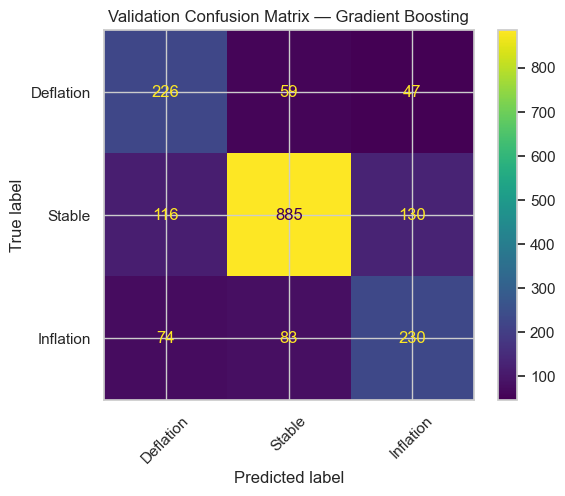

In [57]:

# 1. rebuild preprocessors for model pipelines
# dense one-hot output so all models are compatible.
categorical_transformer_dense = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

numeric_transformer_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

linear_preprocessor_dense = ColumnTransformer([
    ("cat", categorical_transformer_dense, categorical_features),
    ("bin", binary_transformer, binary_features),
    ("num", numeric_transformer_linear, numeric_features)
])

tree_preprocessor_dense = ColumnTransformer([
    ("cat", categorical_transformer_dense, categorical_features),
    ("bin", binary_transformer, binary_features),
    ("num", numeric_transformer_tree, numeric_features)
])

# 2. baseline model pipelines definitions
# separate pipelines to prevent leakage
baseline_models_7d = {
    "Logistic Regression": Pipeline([
        ("preprocess", clone(linear_preprocessor_dense)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

# 3. train and compare
# exclusively on validation data set to determine a promising model
results_7d = []
fitted_models_7d = {}
valid_predictions_7d = {}

class_order = ["Deflation", "Stable", "Inflation"]

for model_name, pipeline in baseline_models_7d.items():
    print(f"Training {model_name} for 7-day target...")
    pipeline.fit(X_train, y7_train)
    
    y_valid_pred = pipeline.predict(X_valid)
    
    acc = accuracy_score(y7_valid, y_valid_pred)
    macro_f1 = f1_score(y7_valid, y_valid_pred, average="macro")
    weighted_f1 = f1_score(y7_valid, y_valid_pred, average="weighted")
    
    results_7d.append({
        "model": model_name,
        "valid_accuracy": acc,
        "valid_macro_f1": macro_f1,
        "valid_weighted_f1": weighted_f1
    })
    
    fitted_models_7d[model_name] = pipeline
    valid_predictions_7d[model_name] = y_valid_pred

results_7d_df = pd.DataFrame(results_7d).sort_values(
    by="valid_macro_f1", ascending=False
).reset_index(drop=True)

display(results_7d_df)

# inspect the best validation model
best_model_name_7d = results_7d_df.loc[0, "model"]
best_model_7d = fitted_models_7d[best_model_name_7d]
best_valid_pred_7d = valid_predictions_7d[best_model_name_7d]

print("Best 7-day baseline model:", best_model_name_7d)

print("\nClassification report on validation set:")
print(classification_report(y7_valid, best_valid_pred_7d, labels=class_order))

ConfusionMatrixDisplay.from_predictions(
    y7_valid,
    best_valid_pred_7d,
    labels=class_order,
    xticks_rotation=45
)
plt.title(f"Validation Confusion Matrix — {best_model_name_7d}")
plt.show()

# Baseline Models (30d)

Training Logistic Regression for 30-day target...
Training Random Forest for 30-day target...
Training Gradient Boosting for 30-day target...


,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,Gradient Boosting,0.458378,0.448806,0.446325
1,Random Forest,0.420541,0.425006,0.418434
2,Logistic Regression,0.426486,0.409432,0.413067


Best 30-day baseline model: Gradient Boosting

Classification report on validation set:
              precision    recall  f1-score   support

   Deflation       0.63      0.49      0.55       515
      Stable       0.48      0.23      0.31       605
   Inflation       0.39      0.62      0.48       730

    accuracy                           0.46      1850
   macro avg       0.50      0.45      0.45      1850
weighted avg       0.49      0.46      0.45      1850



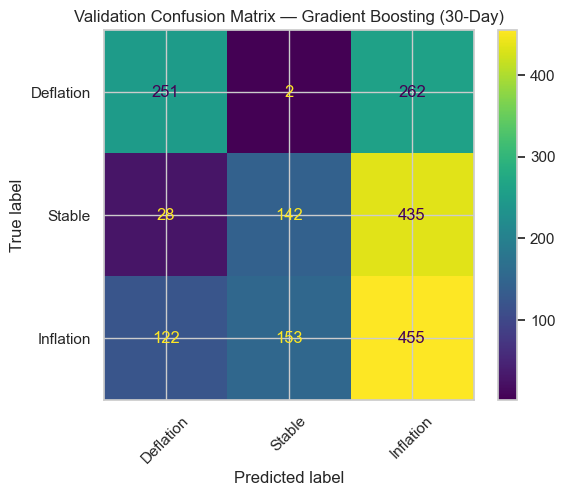


Best-model comparison across horizons:


,target_horizon,best_model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,7-day,Gradient Boosting,0.724865,0.667942,0.731069
1,30-day,Gradient Boosting,0.458378,0.448806,0.446325


In [58]:
# 1. baseline model pipelines definitions
# separate pipelines to prevent leakage
baseline_models_30d = {
    "Logistic Regression": Pipeline([
        ("preprocess", clone(linear_preprocessor_dense)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

# 2. train and compare
# exclusively on validation data set to determine a promising model
results_30d = []
fitted_models_30d = {}
valid_predictions_30d = {}

class_order = ["Deflation", "Stable", "Inflation"]

for model_name, pipeline in baseline_models_30d.items():
    print(f"Training {model_name} for 30-day target...")
    pipeline.fit(X_train, y30_train)
    
    y_valid_pred = pipeline.predict(X_valid)
    
    acc = accuracy_score(y30_valid, y_valid_pred)
    macro_f1 = f1_score(y30_valid, y_valid_pred, average="macro")
    weighted_f1 = f1_score(y30_valid, y_valid_pred, average="weighted")
    
    results_30d.append({
        "model": model_name,
        "valid_accuracy": acc,
        "valid_macro_f1": macro_f1,
        "valid_weighted_f1": weighted_f1
    })
    
    fitted_models_30d[model_name] = pipeline
    valid_predictions_30d[model_name] = y_valid_pred

results_30d_df = pd.DataFrame(results_30d).sort_values(
    by="valid_macro_f1", ascending=False
).reset_index(drop=True)

display(results_30d_df)

# inspect the best validation model
best_model_name_30d = results_30d_df.loc[0, "model"]
best_model_30d = fitted_models_30d[best_model_name_30d]
best_valid_pred_30d = valid_predictions_30d[best_model_name_30d]

print("Best 30-day baseline model:", best_model_name_30d)

print("\nClassification report on validation set:")
print(classification_report(y30_valid, best_valid_pred_30d, labels=class_order))

ConfusionMatrixDisplay.from_predictions(
    y30_valid,
    best_valid_pred_30d,
    labels=class_order,
    xticks_rotation=45
)
plt.title(f"Validation Confusion Matrix — {best_model_name_30d} (30-Day)")
plt.show()

# 7d vs 30d best baselines
comparison_df = pd.DataFrame([
    {
        "target_horizon": "7-day",
        "best_model": best_model_name_7d,
        "valid_accuracy": results_7d_df.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_7d_df.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_7d_df.loc[0, "valid_weighted_f1"]
    },
    {
        "target_horizon": "30-day",
        "best_model": best_model_name_30d,
        "valid_accuracy": results_30d_df.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_30d_df.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_30d_df.loc[0, "valid_weighted_f1"]
    }
])

print("\nBest-model comparison across horizons:")
display(comparison_df)

# Model Evaluation #1

7-day TimeSeries CV results:


,fold,accuracy,macro_f1,weighted_f1
0,1,0.707724,0.673450,0.710618
1,2,0.679193,0.635267,0.677665
2,3,0.657620,0.628405,0.660084
3,4,0.739736,0.725711,0.742483
4,5,0.619346,0.605117,0.621866


30-day TimeSeries CV results:


,fold,accuracy,macro_f1,weighted_f1
0,1,0.648573,0.625196,0.653327
1,2,0.620042,0.607851,0.608787
2,3,0.597773,0.603987,0.598224
3,4,0.757133,0.758697,0.757012
4,5,0.475296,0.497394,0.471114


Cross-validation summary:


,target_horizon,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
0,7-day,0.680724,0.046138,0.653590,0.047211,0.682543,0.046344
1,30-day,0.619763,0.101310,0.618625,0.093127,0.617693,0.103227


Validation summary:


,target_horizon,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,7-day,0.724865,0.667942,0.731069
1,30-day,0.458378,0.448806,0.446325


7-day validation classification report:
              precision    recall  f1-score   support

   Deflation       0.54      0.68      0.60       332
      Stable       0.86      0.78      0.82      1131
   Inflation       0.57      0.59      0.58       387

    accuracy                           0.72      1850
   macro avg       0.66      0.69      0.67      1850
weighted avg       0.74      0.72      0.73      1850

30-day validation classification report:
              precision    recall  f1-score   support

   Deflation       0.63      0.49      0.55       515
      Stable       0.48      0.23      0.31       605
   Inflation       0.39      0.62      0.48       730

    accuracy                           0.46      1850
   macro avg       0.50      0.45      0.45      1850
weighted avg       0.49      0.46      0.45      1850



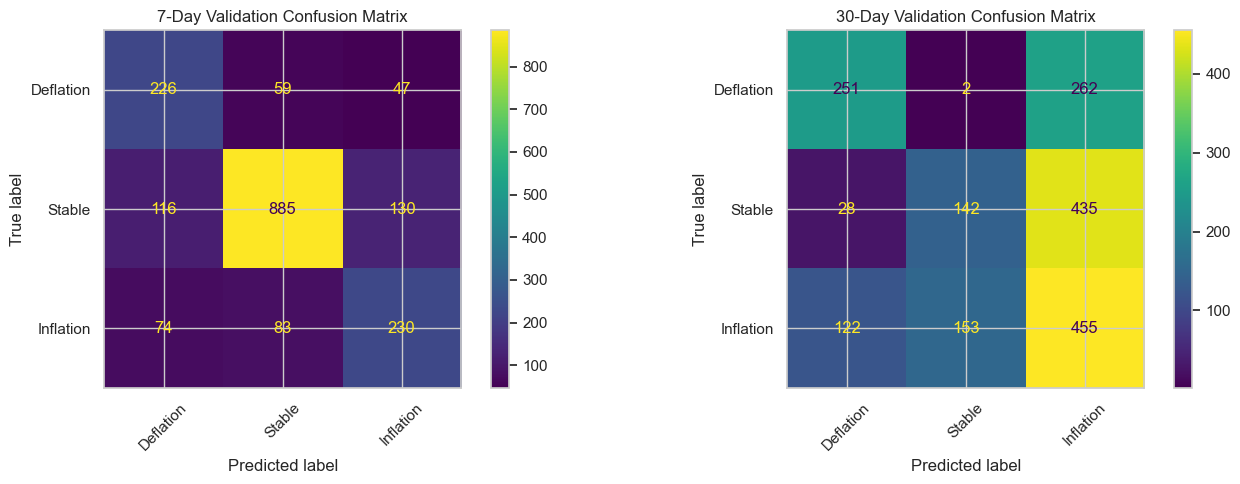

Evaluation artifacts saved.


In [62]:
# 1. best baseline pipelines recreation
gb_pipeline_7d = Pipeline([
    ("preprocess", clone(tree_preprocessor_dense)),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline_30d = Pipeline([
    ("preprocess", clone(tree_preprocessor_dense)),
    ("model", GradientBoostingClassifier(random_state=42))
])

# 2. time-based cross-validation
# on train to check robustness across folds that respect time order
tscv = TimeSeriesSplit(n_splits=5)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

cv_results_7d = cross_validate(
    gb_pipeline_7d,
    X_train,
    y7_train,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_results_30d = cross_validate(
    gb_pipeline_30d,
    X_train,
    y30_train,
    cv=tscv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary_7d = pd.DataFrame({
    "fold": range(1, len(cv_results_7d["test_accuracy"]) + 1),
    "accuracy": cv_results_7d["test_accuracy"],
    "macro_f1": cv_results_7d["test_macro_f1"],
    "weighted_f1": cv_results_7d["test_weighted_f1"]
})

cv_summary_30d = pd.DataFrame({
    "fold": range(1, len(cv_results_30d["test_accuracy"]) + 1),
    "accuracy": cv_results_30d["test_accuracy"],
    "macro_f1": cv_results_30d["test_macro_f1"],
    "weighted_f1": cv_results_30d["test_weighted_f1"]
})

print("7-day TimeSeries CV results:")
display(cv_summary_7d)

print("30-day TimeSeries CV results:")
display(cv_summary_30d)

cv_mean_summary = pd.DataFrame([
    {
        "target_horizon": "7-day",
        "cv_accuracy_mean": cv_summary_7d["accuracy"].mean(),
        "cv_accuracy_std": cv_summary_7d["accuracy"].std(),
        "cv_macro_f1_mean": cv_summary_7d["macro_f1"].mean(),
        "cv_macro_f1_std": cv_summary_7d["macro_f1"].std(),
        "cv_weighted_f1_mean": cv_summary_7d["weighted_f1"].mean(),
        "cv_weighted_f1_std": cv_summary_7d["weighted_f1"].std(),
    },
    {
        "target_horizon": "30-day",
        "cv_accuracy_mean": cv_summary_30d["accuracy"].mean(),
        "cv_accuracy_std": cv_summary_30d["accuracy"].std(),
        "cv_macro_f1_mean": cv_summary_30d["macro_f1"].mean(),
        "cv_macro_f1_std": cv_summary_30d["macro_f1"].std(),
        "cv_weighted_f1_mean": cv_summary_30d["weighted_f1"].mean(),
        "cv_weighted_f1_std": cv_summary_30d["weighted_f1"].std(),
    }
])

print("Cross-validation summary:")
display(cv_mean_summary)

# 3. fitting
# only on train to prevent bias
gb_pipeline_7d.fit(X_train, y7_train)
gb_pipeline_30d.fit(X_train, y30_train)

y7_valid_pred = gb_pipeline_7d.predict(X_valid)
y30_valid_pred = gb_pipeline_30d.predict(X_valid)

class_order = ["Deflation", "Stable", "Inflation"]

valid_eval_summary = pd.DataFrame([
    {
        "target_horizon": "7-day",
        "valid_accuracy": accuracy_score(y7_valid, y7_valid_pred),
        "valid_macro_f1": f1_score(y7_valid, y7_valid_pred, average="macro"),
        "valid_weighted_f1": f1_score(y7_valid, y7_valid_pred, average="weighted"),
    },
    {
        "target_horizon": "30-day",
        "valid_accuracy": accuracy_score(y30_valid, y30_valid_pred),
        "valid_macro_f1": f1_score(y30_valid, y30_valid_pred, average="macro"),
        "valid_weighted_f1": f1_score(y30_valid, y30_valid_pred, average="weighted"),
    }
])

print("Validation summary:")
display(valid_eval_summary)

print("7-day validation classification report:")
print(classification_report(y7_valid, y7_valid_pred, labels=class_order))

print("30-day validation classification report:")
print(classification_report(y30_valid, y30_valid_pred, labels=class_order))

# confusion matrices comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y7_valid, y7_valid_pred,
    labels=class_order,
    xticks_rotation=45,
    ax=axes[0]
)
axes[0].set_title("7-Day Validation Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y30_valid, y30_valid_pred,
    labels=class_order,
    xticks_rotation=45,
    ax=axes[1]
)
axes[1].set_title("30-Day Validation Confusion Matrix")

plt.tight_layout()
plt.show()

# save for later
evaluation_artifacts = {
    "cv_summary_7d": cv_summary_7d,
    "cv_summary_30d": cv_summary_30d,
    "cv_mean_summary": cv_mean_summary,
    "valid_eval_summary": valid_eval_summary,
    "gb_pipeline_7d": gb_pipeline_7d,
    "gb_pipeline_30d": gb_pipeline_30d,
    "y7_valid_pred": y7_valid_pred,
    "y30_valid_pred": y30_valid_pred
}

print("Evaluation artifacts saved.")

# 30d Redesign Option

Candidate 30-day class designs:


,scheme,split,Deflation_pct,Stable_pct,Inflation_pct,notes
0,current_abs_1.0,train,31.90,31.86,36.24,Current 30-day rule
1,current_abs_1.0,valid,27.84,32.70,39.46,Current 30-day rule
2,current_abs_1.0,test,33.77,36.75,29.49,Current 30-day rule
3,abs_2.0,train,28.32,41.48,30.19,Wider symmetric band
4,abs_2.0,valid,22.92,45.57,31.51,Wider symmetric band
5,abs_2.0,test,26.23,51.06,22.71,Wider symmetric band
6,abs_2.5,train,26.84,44.53,28.63,Even wider symmetric band
7,abs_2.5,valid,21.95,50.86,27.19,Even wider symmetric band
8,abs_2.5,test,22.66,55.99,21.36,Even wider symmetric band
9,train_quantile_middle_40,train,30.01,39.99,30.01,"Train-based asymmetric band: [-1.415, 2.038]"


Stable class percentage by split:


split,test,train,valid
scheme,,,
abs_2.0,51.06,41.48,45.57
abs_2.5,55.99,44.53,50.86
current_abs_1.0,36.75,31.86,32.70
train_quantile_middle_40,46.61,39.99,44.54
train_quantile_middle_50,59.84,50.01,59.08


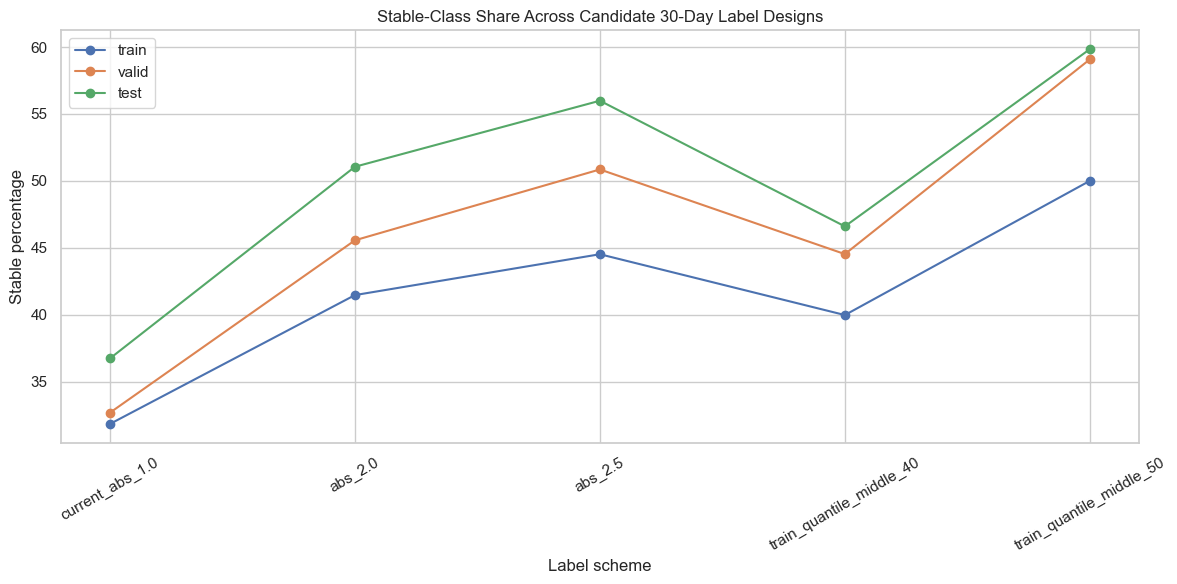

Train-derived quantile thresholds:


,scheme,lower_threshold,upper_threshold
0,train_quantile_middle_40,-1.4153,2.03804
1,train_quantile_middle_50,-3.0172,4.00730


In [63]:
# 30d result was suboptimal, the best baseline model over-estimated stable and high-balled it as inflation
# most-likely root of cause is that the same stable band used for 7d didn't work for 30d's class definition
# as 30d is wider. this section will focus on finding the best band-aid out of all possible candidates

# clean, ordered copy from fe dataset
redesign_df = df_fe.copy().sort_values(["date", "commodity"]).reset_index(drop=True)
target_col_30d = "target_30d_inflation_pct"

# recreate the same split masks using date
dates = redesign_df["date"]
unique_dates = np.array(sorted(dates.unique()))
n_dates = len(unique_dates)

train_cutoff = unique_dates[int(n_dates * 0.70)]
valid_cutoff = unique_dates[int(n_dates * 0.85)]

split_masks = {
    "train": dates <= train_cutoff,
    "valid": (dates > train_cutoff) & (dates <= valid_cutoff),
    "test": dates > valid_cutoff
}

# 1. labeling helpers
# asymmetric bands are considered
def label_with_symmetric_band(x, band):
    if x > band:
        return "Inflation"
    elif x < -band:
        return "Deflation"
    return "Stable"

def make_train_quantile_labeler(train_series, middle_share=0.40):
    """
    middle_share=0.40 means:
    Stable = middle 40% of the TRAIN distribution
    Deflation = bottom 30%
    Inflation = top 30%
    """
    low_q = (1 - middle_share) / 2
    high_q = 1 - low_q
    
    low_threshold = train_series.quantile(low_q)
    high_threshold = train_series.quantile(high_q)
    
    def labeler(x):
        if x > high_threshold:
            return "Inflation"
        elif x < low_threshold:
            return "Deflation"
        return "Stable"
    
    return labeler, low_threshold, high_threshold

# 2. define candidate 30-day label schemes
# quantile thresholds are limited to train set only to prevent leakage
train_30d = redesign_df.loc[split_masks["train"], target_col_30d]

quantile_labeler_40, q40_low, q40_high = make_train_quantile_labeler(
    train_30d, middle_share=0.40
)

quantile_labeler_50, q50_low, q50_high = make_train_quantile_labeler(
    train_30d, middle_share=0.50
)

candidate_schemes = {
    "current_abs_1.0": {
        "type": "symmetric",
        "labeler": lambda x: label_with_symmetric_band(x, 1.0),
        "notes": "Current 30-day rule"
    },
    "abs_2.0": {
        "type": "symmetric",
        "labeler": lambda x: label_with_symmetric_band(x, 2.0),
        "notes": "Wider symmetric band"
    },
    "abs_2.5": {
        "type": "symmetric",
        "labeler": lambda x: label_with_symmetric_band(x, 2.5),
        "notes": "Even wider symmetric band"
    },
    "train_quantile_middle_40": {
        "type": "quantile",
        "labeler": quantile_labeler_40,
        "notes": f"Train-based asymmetric band: [{q40_low:.3f}, {q40_high:.3f}]"
    },
    "train_quantile_middle_50": {
        "type": "quantile",
        "labeler": quantile_labeler_50,
        "notes": f"Train-based asymmetric band: [{q50_low:.3f}, {q50_high:.3f}]"
    }
}

for scheme_name, scheme in candidate_schemes.items():
    redesign_df[f"target_30d_class__{scheme_name}"] = redesign_df[target_col_30d].apply(
        scheme["labeler"]
    )

# class summary table for all schemes
summary_rows = []

for scheme_name, scheme in candidate_schemes.items():
    class_col = f"target_30d_class__{scheme_name}"
    
    for split_name, mask in split_masks.items():
        vc = (
            redesign_df.loc[mask, class_col]
            .value_counts(normalize=True)
            .reindex(["Deflation", "Stable", "Inflation"], fill_value=0)
        )
        
        summary_rows.append({
            "scheme": scheme_name,
            "split": split_name,
            "Deflation_pct": round(vc["Deflation"] * 100, 2),
            "Stable_pct": round(vc["Stable"] * 100, 2),
            "Inflation_pct": round(vc["Inflation"] * 100, 2),
            "notes": scheme["notes"]
        })

label_redesign_summary = pd.DataFrame(summary_rows)

print("Candidate 30-day class designs:")
display(label_redesign_summary)

# compact pivot table for stable class
stable_pivot = label_redesign_summary.pivot(
    index="scheme", columns="split", values="Stable_pct"
)

print("Stable class percentage by split:")
display(stable_pivot)

# graph visualization
stable_plot_df = label_redesign_summary.copy()

fig, ax = plt.subplots(figsize=(12, 6))

for split_name in ["train", "valid", "test"]:
    subset = stable_plot_df[stable_plot_df["split"] == split_name]
    ax.plot(
        subset["scheme"],
        subset["Stable_pct"],
        marker="o",
        label=split_name
    )

ax.set_title("Stable-Class Share Across Candidate 30-Day Label Designs")
ax.set_ylabel("Stable percentage")
ax.set_xlabel("Label scheme")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

# save asymmetric thresholds for later reference
candidate_thresholds = pd.DataFrame([
    {
        "scheme": "train_quantile_middle_40",
        "lower_threshold": q40_low,
        "upper_threshold": q40_high
    },
    {
        "scheme": "train_quantile_middle_50",
        "lower_threshold": q50_low,
        "upper_threshold": q50_high
    }
])

print("Train-derived quantile thresholds:")
display(candidate_thresholds)

# 30d Redesign Implementation

In [65]:
OFFICIAL_30D_LOWER = -1.4153
OFFICIAL_30D_UPPER = 2.0380

def make_30d_class_v2(x, lower=OFFICIAL_30D_LOWER, upper=OFFICIAL_30D_UPPER):
    if x < lower:
        return "Deflation"
    elif x > upper:
        return "Inflation"
    return "Stable"

df_fe["target_30d_class_v2"] = df_fe["target_30d_inflation_pct"].apply(make_30d_class_v2)

# update for future modeling to use the new 30d target
# old 30d class prediction can be used as comparison
secondary_target_class = "target_30d_class_v2"

print("Official 30-day class thresholds:")
print("Lower threshold         :", OFFICIAL_30D_LOWER)
print("Upper threshold         :", OFFICIAL_30D_UPPER)
print("Secondary class target  :", secondary_target_class)

# sanity check
dates = df_fe["date"]
unique_dates = np.array(sorted(dates.unique()))
n_dates = len(unique_dates)

train_cutoff = unique_dates[int(n_dates * 0.70)]
valid_cutoff = unique_dates[int(n_dates * 0.85)]

split_masks = {
    "train": dates <= train_cutoff,
    "valid": (dates > train_cutoff) & (dates <= valid_cutoff),
    "test": dates > valid_cutoff
}

for split_name, mask in split_masks.items():
    print(f"\n30-day class v2 balance — {split_name}")
    display(
        df_fe.loc[mask, "target_30d_class_v2"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reindex(["Deflation", "Stable", "Inflation"])
        .to_frame("percent")
    )

# save updated engineered dataset
processed_path_v2 = PROJECT_ROOT / "data" / "processed" / "pihps_feature_engineered_v2.csv"
df_fe.to_csv(processed_path_v2, index=False)
print("\nSaved updated dataset to:", processed_path_v2)

Official 30-day class thresholds:
Lower threshold         : -1.4153
Upper threshold         : 2.038
Secondary class target  : target_30d_class_v2

30-day class v2 balance — train


,percent
target_30d_class_v2,
Deflation,30.01
Stable,39.99
Inflation,30.01



30-day class v2 balance — valid


,percent
target_30d_class_v2,
Deflation,24.49
Stable,44.54
Inflation,30.97



30-day class v2 balance — test


,percent
target_30d_class_v2,
Deflation,30.79
Stable,46.61
Inflation,22.60



Saved updated dataset to: C:\Users\caran\Desktop\WORK\Projects\Misc\Mercatorie\data\processed\pihps_feature_engineered_v2.csv


# 30d Baseline Retrain

New 30-day target split sizes:
Train: 8625
Valid: 1850
Test : 1845
Training Logistic Regression for redesigned 30-day target...
Training Random Forest for redesigned 30-day target...
Training Gradient Boosting for redesigned 30-day target...
Redesigned 30-day baseline results:


,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,Logistic Regression,0.650811,0.622926,0.653551
1,Gradient Boosting,0.491892,0.505406,0.497380
2,Random Forest,0.464865,0.468930,0.472248


Best redesigned 30-day baseline model: Logistic Regression

Classification report on validation set (30-day v2):
              precision    recall  f1-score   support

   Deflation       0.56      0.44      0.49       453
      Stable       0.84      0.74      0.79       824
   Inflation       0.51      0.69      0.59       573

    accuracy                           0.65      1850
   macro avg       0.64      0.62      0.62      1850
weighted avg       0.67      0.65      0.65      1850



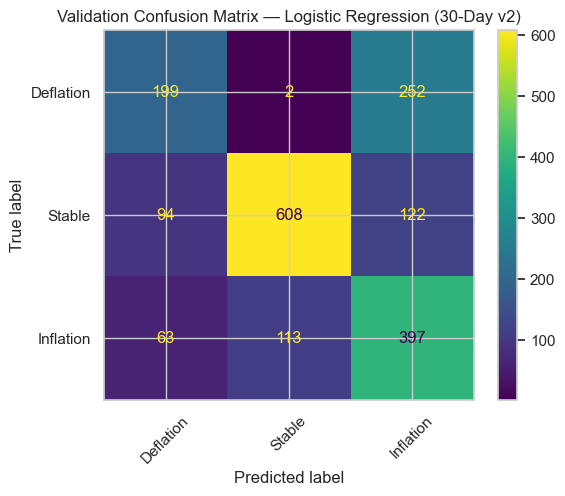

Old vs redesigned 30-day comparison:


,version,best_model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,old_30d_label,Gradient Boosting,0.458378,0.448806,0.446325
1,new_30d_label_v2,Logistic Regression,0.650811,0.622926,0.653551


Relabeling evaluation artifacts saved.


In [66]:
# 1. resplit targets w/ the new 30d label
model_df_v2 = df_fe.copy().sort_values(["date", "commodity"]).reset_index(drop=True)

feature_cols = categorical_features + binary_features + numeric_features
X_v2 = model_df_v2[feature_cols]
y30_v2 = model_df_v2["target_30d_class_v2"]
dates_v2 = model_df_v2["date"]

unique_dates_v2 = np.array(sorted(dates_v2.unique()))
n_dates_v2 = len(unique_dates_v2)

train_cutoff_v2 = unique_dates_v2[int(n_dates_v2 * 0.70)]
valid_cutoff_v2 = unique_dates_v2[int(n_dates_v2 * 0.85)]

train_mask_v2 = dates_v2 <= train_cutoff_v2
valid_mask_v2 = (dates_v2 > train_cutoff_v2) & (dates_v2 <= valid_cutoff_v2)
test_mask_v2  = dates_v2 > valid_cutoff_v2

X_train_v2 = X_v2.loc[train_mask_v2].copy()
X_valid_v2 = X_v2.loc[valid_mask_v2].copy()
X_test_v2  = X_v2.loc[test_mask_v2].copy()

y30_train_v2 = y30_v2.loc[train_mask_v2].copy()
y30_valid_v2 = y30_v2.loc[valid_mask_v2].copy()
y30_test_v2  = y30_v2.loc[test_mask_v2].copy()

print("New 30-day target split sizes:")
print("Train:", len(X_train_v2))
print("Valid:", len(X_valid_v2))
print("Test :", len(X_test_v2))

# 2. baseline model pipelines for 30d v2
baseline_models_30d_v2 = {
    "Logistic Regression": Pipeline([
        ("preprocess", clone(linear_preprocessor_dense)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("preprocess", clone(tree_preprocessor_dense)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}


# 3. train and compare
results_30d_v2 = []
fitted_models_30d_v2 = {}
valid_predictions_30d_v2 = {}

class_order = ["Deflation", "Stable", "Inflation"]

for model_name, pipeline in baseline_models_30d_v2.items():
    print(f"Training {model_name} for redesigned 30-day target...")
    pipeline.fit(X_train_v2, y30_train_v2)
    
    y_valid_pred_v2 = pipeline.predict(X_valid_v2)
    
    acc = accuracy_score(y30_valid_v2, y_valid_pred_v2)
    macro_f1 = f1_score(y30_valid_v2, y_valid_pred_v2, average="macro")
    weighted_f1 = f1_score(y30_valid_v2, y_valid_pred_v2, average="weighted")
    
    results_30d_v2.append({
        "model": model_name,
        "valid_accuracy": acc,
        "valid_macro_f1": macro_f1,
        "valid_weighted_f1": weighted_f1
    })
    
    fitted_models_30d_v2[model_name] = pipeline
    valid_predictions_30d_v2[model_name] = y_valid_pred_v2

results_30d_v2_df = pd.DataFrame(results_30d_v2).sort_values(
    by="valid_macro_f1", ascending=False
).reset_index(drop=True)

print("Redesigned 30-day baseline results:")
display(results_30d_v2_df)


# inspect best redesigned 30d model
best_model_name_30d_v2 = results_30d_v2_df.loc[0, "model"]
best_model_30d_v2 = fitted_models_30d_v2[best_model_name_30d_v2]
best_valid_pred_30d_v2 = valid_predictions_30d_v2[best_model_name_30d_v2]

print("Best redesigned 30-day baseline model:", best_model_name_30d_v2)

print("\nClassification report on validation set (30-day v2):")
print(classification_report(y30_valid_v2, best_valid_pred_30d_v2, labels=class_order))

ConfusionMatrixDisplay.from_predictions(
    y30_valid_v2,
    best_valid_pred_30d_v2,
    labels=class_order,
    xticks_rotation=45
)
plt.title(f"Validation Confusion Matrix — {best_model_name_30d_v2} (30-Day v2)")
plt.show()

# compare old vs redesigned 30d results
old_best_30d = results_30d_df.loc[0]
new_best_30d = results_30d_v2_df.loc[0]

comparison_old_vs_v2 = pd.DataFrame([
    {
        "version": "old_30d_label",
        "best_model": old_best_30d["model"],
        "valid_accuracy": old_best_30d["valid_accuracy"],
        "valid_macro_f1": old_best_30d["valid_macro_f1"],
        "valid_weighted_f1": old_best_30d["valid_weighted_f1"]
    },
    {
        "version": "new_30d_label_v2",
        "best_model": new_best_30d["model"],
        "valid_accuracy": new_best_30d["valid_accuracy"],
        "valid_macro_f1": new_best_30d["valid_macro_f1"],
        "valid_weighted_f1": new_best_30d["valid_weighted_f1"]
    }
])

print("Old vs redesigned 30-day comparison:")
display(comparison_old_vs_v2)

# save for later v2
relabeling_artifacts = {
    "results_30d_v2_df": results_30d_v2_df,
    "best_model_name_30d_v2": best_model_name_30d_v2,
    "best_model_30d_v2": best_model_30d_v2,
    "best_valid_pred_30d_v2": best_valid_pred_30d_v2,
    "comparison_old_vs_v2": comparison_old_vs_v2
}

print("Relabeling evaluation artifacts saved.")

# Hyperparameter Tuning

Tuning 7-day Gradient Boosting...
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Best 7-day params:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 2, 'model__learning_rate': 0.03}
Best 7-day CV macro F1: 0.6887669904582763

7-day tuned validation results:


,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,Gradient Boosting Tuned,0.725405,0.666958,0.730962


7-day tuned classification report:
              precision    recall  f1-score   support

   Deflation       0.56      0.65      0.60       332
      Stable       0.86      0.79      0.82      1131
   Inflation       0.55      0.60      0.58       387

    accuracy                           0.73      1850
   macro avg       0.66      0.68      0.67      1850
weighted avg       0.74      0.73      0.73      1850



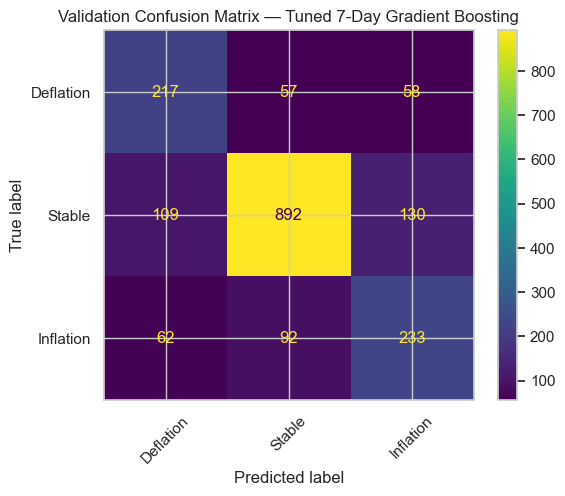

Tuning 30-day v2 Logistic Regression...
Fitting 4 folds for each of 15 candidates, totalling 60 fits

Best 30-day v2 params:
{'model__solver': 'saga', 'model__class_weight': 'balanced', 'model__C': 0.01}
Best 30-day v2 CV macro F1: 0.5307018598131231

30-day v2 tuned validation results:


,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,Logistic Regression Tuned,0.611892,0.601277,0.621078


30-day v2 tuned classification report:
              precision    recall  f1-score   support

   Deflation       0.53      0.58      0.56       453
      Stable       0.82      0.65      0.73       824
   Inflation       0.47      0.58      0.52       573

    accuracy                           0.61      1850
   macro avg       0.61      0.60      0.60      1850
weighted avg       0.64      0.61      0.62      1850



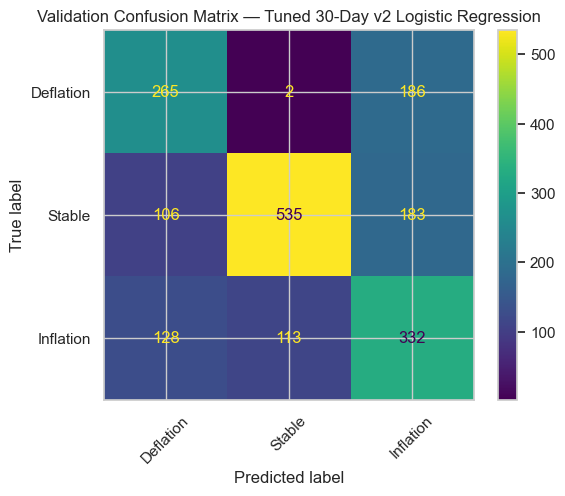

Tuned vs untuned comparison:


,target_horizon,version,model,valid_accuracy,valid_macro_f1,valid_weighted_f1
0,7-day,untuned_baseline,Gradient Boosting,0.724865,0.667942,0.731069
1,7-day,tuned,Gradient Boosting Tuned,0.725405,0.666958,0.730962
2,30-day_v2,untuned_baseline,Logistic Regression,0.650811,0.622926,0.653551
3,30-day_v2,tuned,Logistic Regression Tuned,0.611892,0.601277,0.621078


Tuning artifacts saved.


In [69]:
# 1. time-based CV tuning
# so that every candidate hyperparameter setting is judged realistically
tscv_tune = TimeSeriesSplit(n_splits=4)

# 7d gradient boosting tuning
gb_pipeline_tuned = Pipeline([
    ("preprocess", clone(tree_preprocessor_dense)),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_dist = {
    "model__n_estimators": [100, 150, 200, 300, 400],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.10, 0.15],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

gb_search_7d = RandomizedSearchCV(
    estimator=gb_pipeline_tuned,
    param_distributions=gb_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=tscv_tune,
    n_jobs=-1,
    refit=True,
    verbose=1,
    random_state=42
)

print("Tuning 7-day Gradient Boosting...")
gb_search_7d.fit(X_train, y7_train)

print("\nBest 7-day params:")
print(gb_search_7d.best_params_)
print("Best 7-day CV macro F1:", gb_search_7d.best_score_)

best_gb_7d = gb_search_7d.best_estimator_
y7_valid_pred_tuned = best_gb_7d.predict(X_valid)

results_7d_tuned = pd.DataFrame([{
    "model": "Gradient Boosting Tuned",
    "valid_accuracy": accuracy_score(y7_valid, y7_valid_pred_tuned),
    "valid_macro_f1": f1_score(y7_valid, y7_valid_pred_tuned, average="macro"),
    "valid_weighted_f1": f1_score(y7_valid, y7_valid_pred_tuned, average="weighted")
}])

print("\n7-day tuned validation results:")
display(results_7d_tuned)

print("7-day tuned classification report:")
print(classification_report(y7_valid, y7_valid_pred_tuned, labels=["Deflation", "Stable", "Inflation"]))

ConfusionMatrixDisplay.from_predictions(
    y7_valid,
    y7_valid_pred_tuned,
    labels=["Deflation", "Stable", "Inflation"],
    xticks_rotation=45
)
plt.title("Validation Confusion Matrix — Tuned 7-Day Gradient Boosting")
plt.show()

# 30d v2 logistic regression tuning
lr_pipeline_tuned = Pipeline([
    ("preprocess", clone(linear_preprocessor_dense)),
    ("model", LogisticRegression(max_iter=4000, random_state=42))
])

lr_param_dist = {
    "model__C": [0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 1, 2, 5, 10, 20],
    "model__solver": ["lbfgs", "newton-cg", "saga"],
    "model__class_weight": [None, "balanced"]
}

lr_search_30d_v2 = RandomizedSearchCV(
    estimator=lr_pipeline_tuned,
    param_distributions=lr_param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=tscv_tune,
    n_jobs=-1,
    refit=True,
    verbose=1,
    random_state=42
)

print("Tuning 30-day v2 Logistic Regression...")
lr_search_30d_v2.fit(X_train_v2, y30_train_v2)

print("\nBest 30-day v2 params:")
print(lr_search_30d_v2.best_params_)
print("Best 30-day v2 CV macro F1:", lr_search_30d_v2.best_score_)

best_lr_30d_v2 = lr_search_30d_v2.best_estimator_
y30_valid_pred_tuned = best_lr_30d_v2.predict(X_valid_v2)

results_30d_v2_tuned = pd.DataFrame([{
    "model": "Logistic Regression Tuned",
    "valid_accuracy": accuracy_score(y30_valid_v2, y30_valid_pred_tuned),
    "valid_macro_f1": f1_score(y30_valid_v2, y30_valid_pred_tuned, average="macro"),
    "valid_weighted_f1": f1_score(y30_valid_v2, y30_valid_pred_tuned, average="weighted")
}])

print("\n30-day v2 tuned validation results:")
display(results_30d_v2_tuned)

print("30-day v2 tuned classification report:")
print(classification_report(y30_valid_v2, y30_valid_pred_tuned, labels=["Deflation", "Stable", "Inflation"]))

ConfusionMatrixDisplay.from_predictions(
    y30_valid_v2,
    y30_valid_pred_tuned,
    labels=["Deflation", "Stable", "Inflation"],
    xticks_rotation=45
)
plt.title("Validation Confusion Matrix — Tuned 30-Day v2 Logistic Regression")
plt.show()

# tuned vs untuned comparison
comparison_tuning = pd.DataFrame([
    {
        "target_horizon": "7-day",
        "version": "untuned_baseline",
        "model": results_7d_df.loc[0, "model"],
        "valid_accuracy": results_7d_df.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_7d_df.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_7d_df.loc[0, "valid_weighted_f1"]
    },
    {
        "target_horizon": "7-day",
        "version": "tuned",
        "model": "Gradient Boosting Tuned",
        "valid_accuracy": results_7d_tuned.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_7d_tuned.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_7d_tuned.loc[0, "valid_weighted_f1"]
    },
    {
        "target_horizon": "30-day_v2",
        "version": "untuned_baseline",
        "model": results_30d_v2_df.loc[0, "model"],
        "valid_accuracy": results_30d_v2_df.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_30d_v2_df.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_30d_v2_df.loc[0, "valid_weighted_f1"]
    },
    {
        "target_horizon": "30-day_v2",
        "version": "tuned",
        "model": "Logistic Regression Tuned",
        "valid_accuracy": results_30d_v2_tuned.loc[0, "valid_accuracy"],
        "valid_macro_f1": results_30d_v2_tuned.loc[0, "valid_macro_f1"],
        "valid_weighted_f1": results_30d_v2_tuned.loc[0, "valid_weighted_f1"]
    }
])

print("Tuned vs untuned comparison:")
display(comparison_tuning)

# keep artifacts
tuning_artifacts = {
    "gb_search_7d": gb_search_7d,
    "lr_search_30d_v2": lr_search_30d_v2,
    "best_gb_7d": best_gb_7d,
    "best_lr_30d_v2": best_lr_30d_v2,
    "results_7d_tuned": results_7d_tuned,
    "results_30d_v2_tuned": results_30d_v2_tuned,
    "comparison_tuning": comparison_tuning
}

print("Tuning artifacts saved.")

# Model Explainability

Final official models fitted.
7-day macro F1     : 0.6679423518401895
30-day v2 macro F1 : 0.6229255636044155
Top permutation importances — 7-day model


,feature,importance_mean,importance_std
11,price_change_7d_pct,0.037296,0.005469
0,commodity,0.035612,0.006448
10,price_change_1d_pct,0.022827,0.006259
17,volatility_30d_pct,0.019289,0.004691
26,lag_gap_1_7_pct,0.016172,0.004643
6,price_idr,0.014334,0.003663
24,price_zscore_30d,0.008519,0.002165
12,price_change_30d_pct,0.005433,0.001932
16,price_vs_ma30_pct,0.005356,0.002023
19,month_cos,0.004960,0.003108


Top permutation importances — 30-day v2 model


,feature,importance_mean,importance_std
14,rolling_mean_30d,0.251821,0.009355
6,price_idr,0.223380,0.010169
0,commodity,0.185679,0.010712
7,price_lag_1d,0.149481,0.009073
13,rolling_mean_7d,0.079962,0.008930
8,price_lag_7d,0.061894,0.008443
21,week_cos,0.038990,0.007866
27,lag_gap_7_30_pct,0.034073,0.007552
28,momentum_gap_7_30_pct,0.027698,0.004202
24,price_zscore_30d,0.017938,0.004937


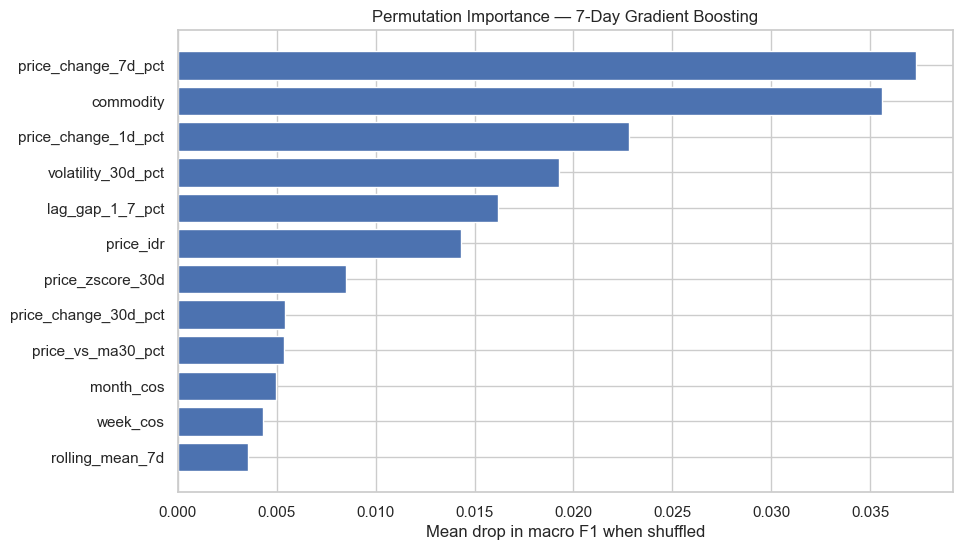

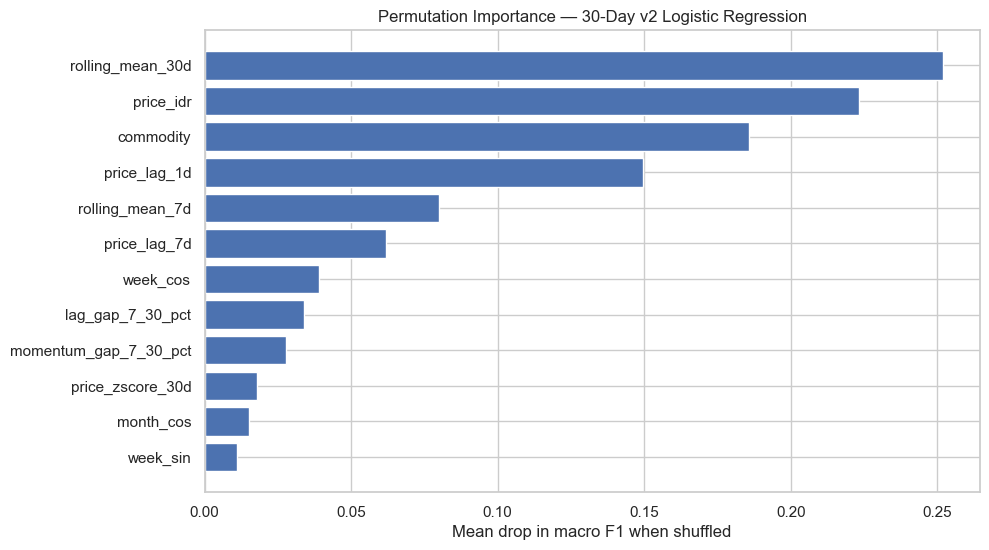

Top native feature importances — 7-day Gradient Boosting


,feature,importance
10,num__price_idr,0.297954
15,num__price_change_7d_pct,0.196820
30,num__lag_gap_1_7_pct,0.065869
14,num__price_change_1d_pct,0.049128
18,num__rolling_mean_30d,0.046498
21,num__volatility_30d_pct,0.036695
20,num__price_vs_ma30_pct,0.035087
13,num__price_lag_30d,0.032124
28,num__price_zscore_30d,0.027082
25,num__week_cos,0.025891


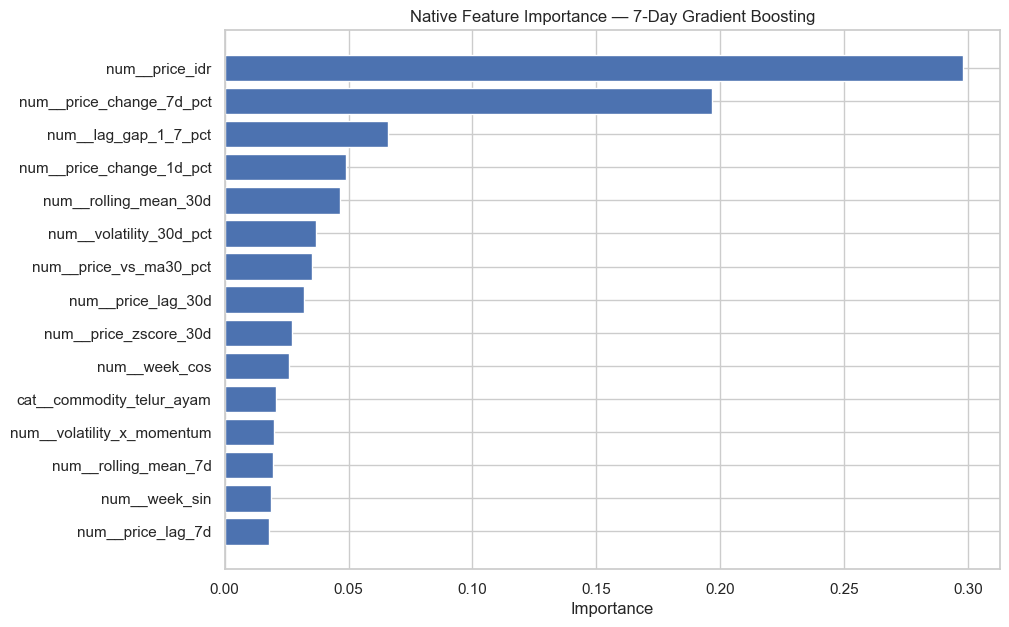

Top positive coefficients for class = Deflation


,feature,coefficient
18,num__rolling_mean_30d,1.920467
11,num__price_lag_1d,0.953042
31,num__lag_gap_7_30_pct,0.669068
17,num__rolling_mean_7d,0.614561
1,cat__commodity_beras,0.533542
32,num__momentum_gap_7_30_pct,0.495068
3,cat__commodity_minyak_goreng,0.493651
12,num__price_lag_7d,0.330051
15,num__price_change_7d_pct,0.319044
20,num__price_vs_ma30_pct,0.314961


Top negative coefficients for class = Deflation


,feature,coefficient
10,num__price_idr,-2.350002
2,cat__commodity_cabai_merah,-0.913733
16,num__price_change_30d_pct,-0.231631
0,cat__commodity_bawang_merah,-0.227393
13,num__price_lag_30d,-0.166642
25,num__week_cos,-0.149676
8,bin__high_vol_regime,-0.139746
19,num__rolling_std_30d,-0.139040
29,num__ma_gap_7_30_pct,-0.133379
28,num__price_zscore_30d,-0.121390


Top positive coefficients for class = Inflation


...

,feature,coefficient
1,cat__commodity_beras,1.281413
17,num__rolling_mean_7d,0.594024
16,num__price_change_30d_pct,0.473031
3,cat__commodity_minyak_goreng,0.471870
12,num__price_lag_7d,0.316393
10,num__price_idr,0.238976
13,num__price_lag_30d,0.230656
30,num__lag_gap_1_7_pct,0.134642
14,num__price_change_1d_pct,0.102592
8,bin__high_vol_regime,0.102368


Top negative coefficients for class = Stable


,feature,coefficient
18,num__rolling_mean_30d,-1.837347
31,num__lag_gap_7_30_pct,-1.237593
0,cat__commodity_bawang_merah,-0.899556
32,num__momentum_gap_7_30_pct,-0.868205
2,cat__commodity_cabai_merah,-0.535685
15,num__price_change_7d_pct,-0.447471
6,bin__is_month_start,-0.383500
4,cat__commodity_telur_ayam,-0.311831
9,num__year,-0.157782
29,num__ma_gap_7_30_pct,-0.154478


Top absolute coefficients across all 30-day classes


,feature,max_abs_coefficient
10,num__price_idr,2.350002
18,num__rolling_mean_30d,1.920467
1,cat__commodity_beras,1.814954
2,cat__commodity_cabai_merah,1.449418
31,num__lag_gap_7_30_pct,1.237593
17,num__rolling_mean_7d,1.208585
0,cat__commodity_bawang_merah,1.126948
3,cat__commodity_minyak_goreng,0.965521
11,num__price_lag_1d,0.953042
32,num__momentum_gap_7_30_pct,0.868205


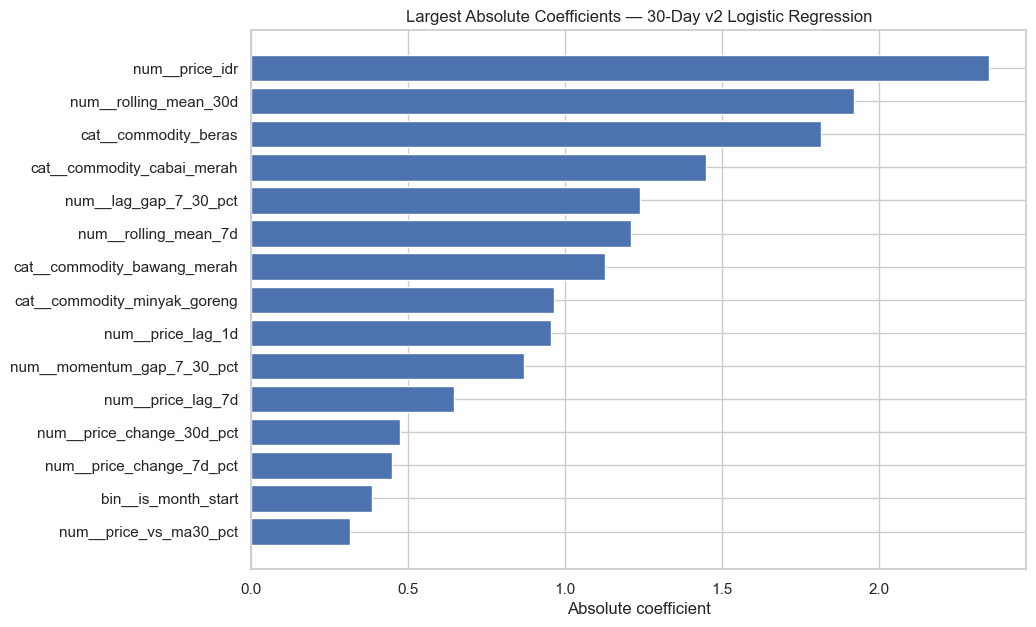

Explainability artifacts saved.


In [77]:
# 1. refit official final models
final_model_7d = Pipeline([
    ("preprocess", clone(tree_preprocessor_dense)),
    ("model", GradientBoostingClassifier(random_state=42))
])

final_model_30d = Pipeline([
    ("preprocess", clone(linear_preprocessor_dense)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

final_model_7d.fit(X_train, y7_train)
final_model_30d.fit(X_train_v2, y30_train_v2)

print("Final official models fitted.")

# 2. validation performance sanity check
y7_valid_pred_final = final_model_7d.predict(X_valid)
y30_valid_pred_final = final_model_30d.predict(X_valid_v2)

print("7-day macro F1     :", f1_score(y7_valid, y7_valid_pred_final, average="macro"))
print("30-day v2 macro F1 :", f1_score(y30_valid_v2, y30_valid_pred_final, average="macro"))

# 3. permutation importance on RAW features
# (the whole pipeline is measured: categorical encoding, scaling, tree/linear logic, etc)
perm_7d = permutation_importance(
    final_model_7d,
    X_valid,
    y7_valid,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_30d = permutation_importance(
    final_model_30d,
    X_valid_v2,
    y30_valid_v2,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_7d_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm_7d.importances_mean,
    "importance_std": perm_7d.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_30d_df = pd.DataFrame({
    "feature": X_valid_v2.columns,
    "importance_mean": perm_30d.importances_mean,
    "importance_std": perm_30d.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top permutation importances — 7-day model")
display(perm_importance_7d_df.head(15))

print("Top permutation importances — 30-day v2 model")
display(perm_importance_30d_df.head(15))

# top 12 for each
top_n = 12

plt.figure(figsize=(10, 6))
plt.barh(
    perm_importance_7d_df.head(top_n)["feature"][::-1],
    perm_importance_7d_df.head(top_n)["importance_mean"][::-1]
)
plt.title("Permutation Importance — 7-Day Gradient Boosting")
plt.xlabel("Mean drop in macro F1 when shuffled")
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(
    perm_importance_30d_df.head(top_n)["feature"][::-1],
    perm_importance_30d_df.head(top_n)["importance_mean"][::-1]
)
plt.title("Permutation Importance — 30-Day v2 Logistic Regression")
plt.xlabel("Mean drop in macro F1 when shuffled")
plt.show()

# 4. native feature-importance
# tells which transformed features were used most in boosted trees
gb_preprocessor = final_model_7d.named_steps["preprocess"]
gb_model = final_model_7d.named_steps["model"]

gb_feature_names = gb_preprocessor.get_feature_names_out()

gb_native_importance_df = pd.DataFrame({
    "feature": gb_feature_names,
    "importance": gb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top native feature importances — 7-day Gradient Boosting")
display(gb_native_importance_df.head(20))

plt.figure(figsize=(10, 7))
plt.barh(
    gb_native_importance_df.head(15)["feature"][::-1],
    gb_native_importance_df.head(15)["importance"][::-1]
)
plt.title("Native Feature Importance — 7-Day Gradient Boosting")
plt.xlabel("Importance")
plt.show()

# 5. coefficient analysis for 30d v2 logistic regression
# for multiclass logistic regression, coef_ has one row per class.
# (+)coeff for class inflation = the feature pushes the model toward predicting inflation
lr_preprocessor = final_model_30d.named_steps["preprocess"]
lr_model = final_model_30d.named_steps["model"]

lr_feature_names = lr_preprocessor.get_feature_names_out()
class_names = lr_model.classes_

coef_tables = {}

for class_idx, class_name in enumerate(class_names):
    coef_df = pd.DataFrame({
        "feature": lr_feature_names,
        "coefficient": lr_model.coef_[class_idx]
    }).sort_values("coefficient", ascending=False)
    
    coef_tables[class_name] = coef_df
    
    print(f"Top positive coefficients for class = {class_name}")
    display(coef_df.head(12))
    
    print(f"Top negative coefficients for class = {class_name}")
    display(coef_df.tail(12).sort_values("coefficient", ascending=True))

# compact absolute-coefficient view
lr_abs_coef_df = pd.DataFrame({
    "feature": lr_feature_names,
    "max_abs_coefficient": np.abs(lr_model.coef_).max(axis=0)
}).sort_values("max_abs_coefficient", ascending=False)

print("Top absolute coefficients across all 30-day classes")
display(lr_abs_coef_df.head(20))

plt.figure(figsize=(10, 7))
plt.barh(
    lr_abs_coef_df.head(15)["feature"][::-1],
    lr_abs_coef_df.head(15)["max_abs_coefficient"][::-1]
)
plt.title("Largest Absolute Coefficients — 30-Day v2 Logistic Regression")
plt.xlabel("Absolute coefficient")
plt.show()

# save for later
explainability_artifacts = {
    "final_model_7d": final_model_7d,
    "final_model_30d": final_model_30d,
    "perm_importance_7d_df": perm_importance_7d_df,
    "perm_importance_30d_df": perm_importance_30d_df,
    "gb_native_importance_df": gb_native_importance_df,
    "lr_abs_coef_df": lr_abs_coef_df,
    "coef_tables": coef_tables
}

print("Explainability artifacts saved.")

# Error Analysis

Validation Analysis

In [78]:
# 7d validation frame
error_7d = X_valid.copy()
error_7d["date"] = model_df.loc[X_valid.index, "date"].values
error_7d["commodity"] = model_df.loc[X_valid.index, "commodity"].values
error_7d["true_class"] = y7_valid.values
error_7d["pred_class"] = final_model_7d.predict(X_valid)
error_7d["correct"] = (error_7d["true_class"] == error_7d["pred_class"]).astype(int)
error_7d["is_error"] = 1 - error_7d["correct"]

proba_7d = final_model_7d.predict_proba(X_valid)
class_order_7d = final_model_7d.named_steps["model"].classes_
proba_7d_df = pd.DataFrame(proba_7d, columns=[f"proba_{c}" for c in class_order_7d], index=X_valid.index)

error_7d = pd.concat([error_7d, proba_7d_df], axis=1)
error_7d["pred_confidence"] = proba_7d.max(axis=1)

# 30d v2 validation frame
error_30d = X_valid_v2.copy()
error_30d["date"] = model_df_v2.loc[X_valid_v2.index, "date"].values
error_30d["commodity"] = model_df_v2.loc[X_valid_v2.index, "commodity"].values
error_30d["true_class"] = y30_valid_v2.values
error_30d["pred_class"] = final_model_30d.predict(X_valid_v2)
error_30d["correct"] = (error_30d["true_class"] == error_30d["pred_class"]).astype(int)
error_30d["is_error"] = 1 - error_30d["correct"]

proba_30d = final_model_30d.predict_proba(X_valid_v2)
class_order_30d = final_model_30d.named_steps["model"].classes_
proba_30d_df = pd.DataFrame(proba_30d, columns=[f"proba_{c}" for c in class_order_30d], index=X_valid_v2.index)

error_30d = pd.concat([error_30d, proba_30d_df], axis=1)
error_30d["pred_confidence"] = proba_30d.max(axis=1)

print("7-day validation error table shape:", error_7d.shape)
print("30-day v2 validation error table shape:", error_30d.shape)

7-day validation error table shape: (1850, 39)
30-day v2 validation error table shape: (1850, 39)


Overall Error Rate by Commodity

In [79]:
def summarize_by_commodity(df, label):
    summary = (
        df.groupby("commodity")
          .agg(
              n=("commodity", "size"),
              accuracy=("correct", "mean"),
              error_rate=("is_error", "mean"),
              avg_confidence=("pred_confidence", "mean"),
              avg_volatility_30d=("volatility_30d_pct", "mean"),
              high_vol_share=("high_vol_regime", "mean")
          )
          .sort_values("error_rate", ascending=False)
    )
    summary[["accuracy", "error_rate", "avg_confidence", "high_vol_share"]] *= 100
    print(f"\nCommodity summary — {label}")
    display(summary.round(2))
    return summary

commodity_summary_7d = summarize_by_commodity(error_7d, "7-day")
commodity_summary_30d = summarize_by_commodity(error_30d, "30-day v2")


Commodity summary — 7-day


,n,accuracy,error_rate,avg_confidence,avg_volatility_30d,high_vol_share
commodity,,,,,,
cabai_merah,370,56.22,43.78,63.50,1.51,0.0
bawang_merah,370,57.30,42.70,62.55,0.52,0.0
telur_ayam,370,59.46,40.54,60.82,0.29,0.0
beras,370,91.35,8.65,90.76,0.26,0.0
minyak_goreng,370,98.11,1.89,73.55,0.19,0.0



Commodity summary — 30-day v2


,n,accuracy,error_rate,avg_confidence,avg_volatility_30d,high_vol_share
commodity,,,,,,
telur_ayam,370,48.65,51.35,52.39,0.29,0.0
cabai_merah,370,53.51,46.49,62.82,1.51,0.0
bawang_merah,370,58.92,41.08,60.81,0.52,0.0
beras,370,69.19,30.81,83.21,0.26,0.0
minyak_goreng,370,95.14,4.86,51.39,0.19,0.0


Error Rate by True Class

In [80]:
def summarize_by_true_class(df, label):
    summary = (
        df.groupby("true_class")
          .agg(
              n=("true_class", "size"),
              accuracy=("correct", "mean"),
              error_rate=("is_error", "mean"),
              avg_confidence=("pred_confidence", "mean")
          )
          .sort_values("error_rate", ascending=False)
    )
    summary[["accuracy", "error_rate", "avg_confidence"]] *= 100
    print(f"\nTrue-class summary — {label}")
    display(summary.round(2))
    return summary

class_summary_7d = summarize_by_true_class(error_7d, "7-day")
class_summary_30d = summarize_by_true_class(error_30d, "30-day v2")


True-class summary — 7-day


,n,accuracy,error_rate,avg_confidence
true_class,,,,
Inflation,387,59.43,40.57,61.75
Deflation,332,68.07,31.93,67.12
Stable,1131,78.25,21.75,74.05



True-class summary — 30-day v2


,n,accuracy,error_rate,avg_confidence
true_class,,,,
Deflation,453,43.93,56.07,57.31
Inflation,573,69.28,30.72,64.97
Stable,824,73.79,26.21,62.79


Error Rate by Volatility Regime

In [81]:
def summarize_by_regime(df, label):
    regime_map = {0: "Normal volatility", 1: "High volatility"}
    tmp = df.copy()
    tmp["vol_regime_label"] = tmp["high_vol_regime"].map(regime_map)
    
    summary = (
        tmp.groupby("vol_regime_label")
           .agg(
               n=("vol_regime_label", "size"),
               accuracy=("correct", "mean"),
               error_rate=("is_error", "mean"),
               avg_confidence=("pred_confidence", "mean")
           )
           .sort_values("error_rate", ascending=False)
    )
    summary[["accuracy", "error_rate", "avg_confidence"]] *= 100
    print(f"\nVolatility regime summary — {label}")
    display(summary.round(2))
    return summary

regime_summary_7d = summarize_by_regime(error_7d, "7-day")
regime_summary_30d = summarize_by_regime(error_30d, "30-day v2")


Volatility regime summary — 7-day


,n,accuracy,error_rate,avg_confidence
vol_regime_label,,,,
Normal volatility,1850,72.49,27.51,70.24



Volatility regime summary — 30-day v2


,n,accuracy,error_rate,avg_confidence
vol_regime_label,,,,
Normal volatility,1850,65.08,34.92,62.12


Monthly Error Trend


Monthly error summary — 7-day


,year_month,n,accuracy,error_rate
1,2022-11-01,150,67.33,32.67
2,2022-12-01,155,69.68,30.32
3,2023-01-01,155,67.74,32.26
4,2023-02-01,140,66.43,33.57
5,2023-03-01,155,65.81,34.19
6,2023-04-01,150,67.33,32.67
7,2023-05-01,155,73.55,26.45
8,2023-06-01,150,74.67,25.33
9,2023-07-01,155,88.39,11.61
10,2023-08-01,155,80.00,20.00


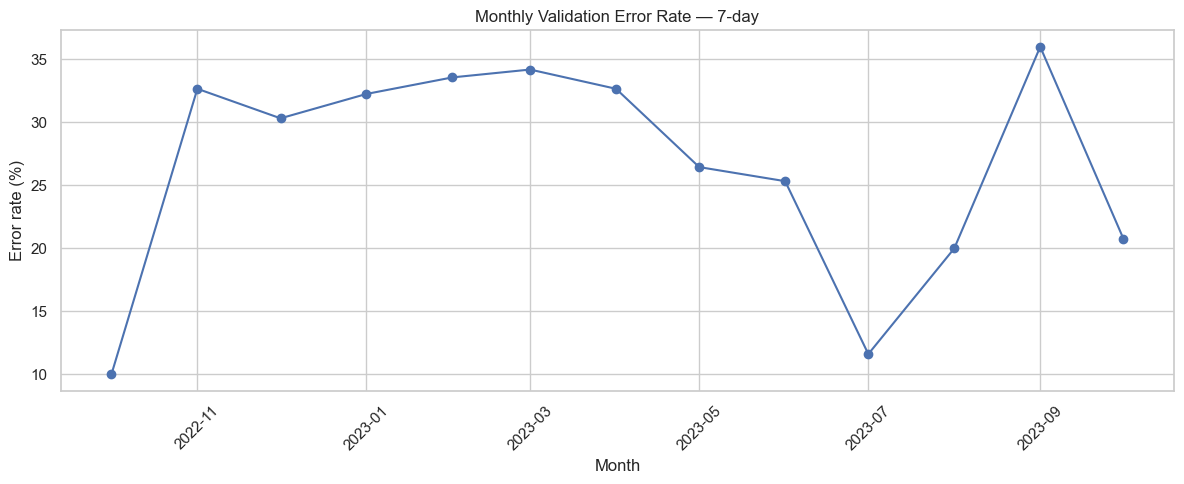


Monthly error summary — 30-day v2


,year_month,n,accuracy,error_rate
1,2022-11-01,150,78.67,21.33
2,2022-12-01,155,78.71,21.29
3,2023-01-01,155,43.23,56.77
4,2023-02-01,140,73.57,26.43
5,2023-03-01,155,52.90,47.10
6,2023-04-01,150,74.67,25.33
7,2023-05-01,155,62.58,37.42
8,2023-06-01,150,58.00,42.00
9,2023-07-01,155,72.90,27.10
10,2023-08-01,155,50.32,49.68


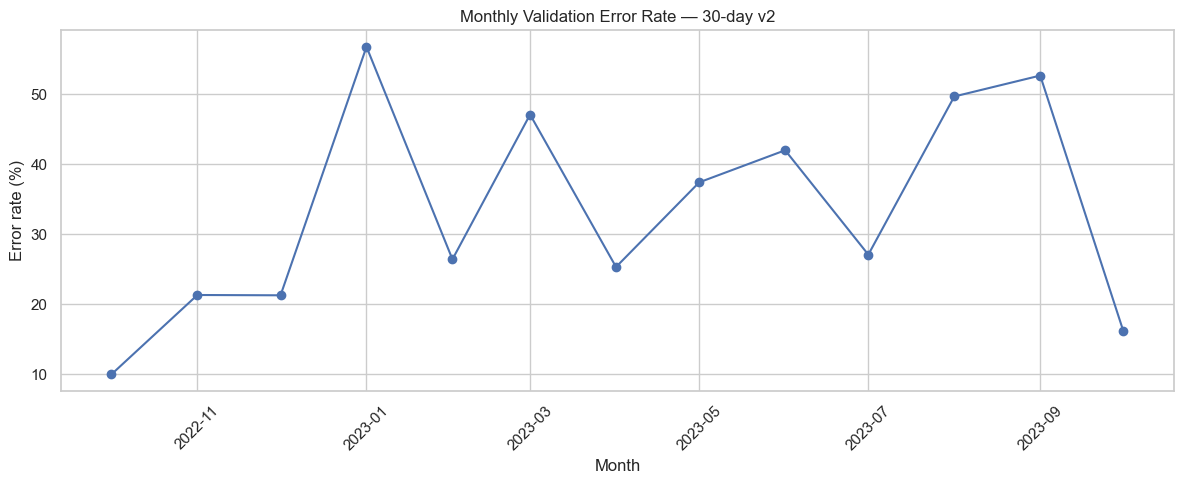

In [82]:
def monthly_error_summary(df, label):
    tmp = df.copy()
    tmp["year_month"] = pd.to_datetime(tmp["date"]).dt.to_period("M").dt.to_timestamp()
    
    summary = (
        tmp.groupby("year_month")
           .agg(
               n=("year_month", "size"),
               accuracy=("correct", "mean"),
               error_rate=("is_error", "mean")
           )
           .reset_index()
    )
    summary[["accuracy", "error_rate"]] *= 100
    
    print(f"\nMonthly error summary — {label}")
    display(summary.tail(12).round(2))
    
    plt.figure(figsize=(12, 5))
    plt.plot(summary["year_month"], summary["error_rate"], marker="o")
    plt.title(f"Monthly Validation Error Rate — {label}")
    plt.xlabel("Month")
    plt.ylabel("Error rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return summary

monthly_error_7d = monthly_error_summary(error_7d, "7-day")
monthly_error_30d = monthly_error_summary(error_30d, "30-day v2")

Commodity x True Class Error Matrix

In [83]:
def commodity_class_error_matrix(df, label):
    matrix = (
        df.groupby(["commodity", "true_class"])["is_error"]
          .mean()
          .unstack()
          .reindex(columns=["Deflation", "Stable", "Inflation"])
    ) * 100
    
    print(f"\nCommodity × true-class error rate (%) — {label}")
    display(matrix.round(2))
    return matrix

commodity_class_errors_7d = commodity_class_error_matrix(error_7d, "7-day")
commodity_class_errors_30d = commodity_class_error_matrix(error_30d, "30-day v2")


Commodity × true-class error rate (%) — 7-day


true_class,Deflation,Stable,Inflation
commodity,,,
bawang_merah,22.76,78.86,27.45
beras,100.00,0.90,80.65
cabai_merah,23.39,100.00,36.87
minyak_goreng,100.00,0.82,NaN
telur_ayam,65.45,31.67,50.67



Commodity × true-class error rate (%) — 30-day v2


true_class,Deflation,Stable,Inflation
commodity,,,
bawang_merah,56.91,100.00,5.52
beras,100.00,0.00,100.00
cabai_merah,73.11,100.00,22.07
minyak_goreng,100.00,4.61,NaN
telur_ayam,40.28,100.00,7.84


High Confidence False Predictions

In [84]:
def high_confidence_errors(df, label, top_n=15):
    cols_to_show = [
        "date", "commodity", "true_class", "pred_class", "pred_confidence",
        "price_idr", "price_change_1d_pct", "price_change_7d_pct", "price_change_30d_pct",
        "price_zscore_30d", "volatility_30d_pct", "high_vol_regime"
    ]
    
    worst = (
        df[df["is_error"] == 1]
        .sort_values("pred_confidence", ascending=False)
        [cols_to_show]
        .head(top_n)
    )
    
    print(f"\nTop {top_n} high-confidence wrong predictions — {label}")
    display(worst)
    return worst

high_conf_wrong_7d = high_confidence_errors(error_7d, "7-day")
high_conf_wrong_30d = high_confidence_errors(error_30d, "30-day v2")


Top 15 high-confidence wrong predictions — 7-day


,date,commodity,true_class,pred_class,pred_confidence,price_idr,price_change_1d_pct,price_change_7d_pct,price_change_30d_pct,price_zscore_30d,volatility_30d_pct,high_vol_regime
9426,2023-03-31,beras,Deflation,Stable,0.957771,13400.0,0.0000,0.3745,1.5152,1.545015,0.2916,0
10141,2023-08-21,beras,Inflation,Stable,0.949220,13600.0,0.0000,0.0000,0.3690,1.308450,0.1176,0
10211,2023-09-04,beras,Inflation,Stable,0.946894,13900.0,0.7246,1.0909,2.5830,2.374400,0.2074,0
9436,2023-04-02,beras,Deflation,Stable,0.943696,13400.0,0.0000,0.3745,1.5152,1.345593,0.2916,0
9431,2023-04-01,beras,Deflation,Stable,0.943696,13400.0,0.0000,0.3745,1.5152,1.438391,0.2916,0
8821,2022-11-30,beras,Inflation,Stable,0.943667,12300.0,0.0000,0.4082,0.8197,1.636505,0.1038,0
10206,2023-09-03,beras,Inflation,Stable,0.939164,13800.0,0.0000,0.7299,1.8450,1.652553,0.1690,0
10201,2023-09-02,beras,Inflation,Stable,0.939164,13800.0,0.0000,0.7299,1.8450,1.801995,0.1690,0
10196,2023-09-01,beras,Inflation,Stable,0.937767,13800.0,0.0000,0.7299,1.8450,1.983618,0.1690,0
10151,2023-08-23,beras,Inflation,Stable,0.933940,13650.0,0.0000,0.3676,0.7380,2.307619,0.1342,0



Top 15 high-confidence wrong predictions — 30-day v2


,date,commodity,true_class,pred_class,pred_confidence,price_idr,price_change_1d_pct,price_change_7d_pct,price_change_30d_pct,price_zscore_30d,volatility_30d_pct,high_vol_regime
10061,2023-08-05,beras,Inflation,Stable,0.869969,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10091,2023-08-11,beras,Inflation,Stable,0.868844,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10066,2023-08-06,beras,Inflation,Stable,0.868712,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10096,2023-08-12,beras,Inflation,Stable,0.866165,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10071,2023-08-07,beras,Inflation,Stable,0.866099,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10086,2023-08-10,beras,Inflation,Stable,0.864952,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10101,2023-08-13,beras,Inflation,Stable,0.864911,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10076,2023-08-08,beras,Inflation,Stable,0.862706,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10081,2023-08-09,beras,Inflation,Stable,0.862188,13550.0,0.0000,0.000,0.0000,0.182573,0.1945,0
10126,2023-08-18,beras,Inflation,Stable,0.861418,13600.0,-0.3663,0.369,1.1152,1.652094,0.1778,0


# Prediction System

In [85]:
# refit
predict_model_7d = Pipeline([
    ("preprocess", clone(tree_preprocessor_dense)),
    ("model", GradientBoostingClassifier(random_state=42))
])

predict_model_30d = Pipeline([
    ("preprocess", clone(linear_preprocessor_dense)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

predict_model_7d.fit(X_train, y7_train)
predict_model_30d.fit(X_train_v2, y30_train_v2)

prediction_bundle = {
    "7d": {
        "model_name": "Gradient Boosting",
        "target_name": "target_7d_class",
        "model": predict_model_7d
    },
    "30d": {
        "model_name": "Logistic Regression",
        "target_name": "target_30d_class_v2",
        "model": predict_model_30d
    }
}

print("Prediction bundle ready.")

Prediction bundle ready.


In [ ]:
# input validation
required_feature_cols = feature_cols.copy()

def validate_prediction_input(df_input, required_cols=required_feature_cols):
    missing_cols = [col for col in required_cols if col not in df_input.columns]
    extra_cols = [col for col in df_input.columns if col not in required_cols]
    
    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")
    
    # reorder columns per schema
    df_input = df_input[required_cols].copy()
    return df_input, extra_cols

In [88]:
# main prediction function
def predict_inflation(df_input, horizon="7d"):
    """
    Predict inflation class for one or more rows.

    Parameters
    ----------
    df_input : pd.DataFrame
        Must contain exactly the model feature columns.
    horizon : str
        "7d" or "30d"

    Returns
    -------
    pd.DataFrame
        Structured predictions with class probabilities.
    """
    if horizon not in prediction_bundle:
        raise ValueError("horizon must be one of: '7d', '30d'")
    
    model_info = prediction_bundle[horizon]
    model = model_info["model"]
    model_name = model_info["model_name"]
    
    df_input_validated, extra_cols = validate_prediction_input(df_input)
    
    pred_class = model.predict(df_input_validated)
    pred_proba = model.predict_proba(df_input_validated)
    class_labels = model.named_steps["model"].classes_
    
    result = pd.DataFrame({
        "horizon": horizon,
        "model_name": model_name,
        "predicted_class": pred_class,
        "prediction_confidence": pred_proba.max(axis=1)
    }, index=df_input_validated.index)
    
    proba_df = pd.DataFrame(
        pred_proba,
        columns=[f"prob_{c}" for c in class_labels],
        index=df_input_validated.index
    )
    
    result = pd.concat([result, proba_df], axis=1)
    
    if extra_cols:
        print("Ignored extra columns:", extra_cols)
    
    return result

In [89]:
# single-row wrapper
def predict_single_observation(feature_dict, horizon="7d"):
    """
    Predict from a single dictionary of features.
    """
    df_input = pd.DataFrame([feature_dict])
    result = predict_inflation(df_input, horizon=horizon)
    return result.iloc[0].to_dict()

In [90]:
# example using 1st validation set row
example_row = X_valid.iloc[[0]].copy()

pred_example_7d = predict_inflation(example_row, horizon="7d")
pred_example_30d = predict_inflation(example_row, horizon="30d")

print("Example 7-day prediction:")
display(pred_example_7d)

print("Example 30-day prediction:")
display(pred_example_30d)

Example 7-day prediction:


,horizon,model_name,predicted_class,prediction_confidence,prob_Deflation,prob_Inflation,prob_Stable
8625,7d,Gradient Boosting,Stable,0.575969,0.204756,0.219274,0.575969


Example 30-day prediction:


,horizon,model_name,predicted_class,prediction_confidence,prob_Deflation,prob_Inflation,prob_Stable
8625,30d,Logistic Regression,Inflation,0.51086,0.44323,0.51086,0.045911


In [91]:
# batch example from few validation set rows
batch_example = X_valid.head(5).copy()

batch_pred_7d = predict_inflation(batch_example, horizon="7d")
batch_pred_30d = predict_inflation(batch_example, horizon="30d")

print("Batch prediction example — 7-day")
display(batch_pred_7d)

print("Batch prediction example — 30-day")
display(batch_pred_30d)

Batch prediction example — 7-day


,horizon,model_name,predicted_class,prediction_confidence,prob_Deflation,prob_Inflation,prob_Stable
8625,7d,Gradient Boosting,Stable,0.575969,0.204756,0.219274,0.575969
8626,7d,Gradient Boosting,Stable,0.921493,0.026329,0.052178,0.921493
8627,7d,Gradient Boosting,Deflation,0.662823,0.662823,0.264494,0.072683
8628,7d,Gradient Boosting,Stable,0.847780,0.063225,0.088995,0.847780
8629,7d,Gradient Boosting,Stable,0.698082,0.135531,0.166387,0.698082


Batch prediction example — 30-day


,horizon,model_name,predicted_class,prediction_confidence,prob_Deflation,prob_Inflation,prob_Stable
8625,30d,Logistic Regression,Inflation,0.510860,0.443230,0.510860,0.045911
8626,30d,Logistic Regression,Stable,0.859429,0.065151,0.075420,0.859429
8627,30d,Logistic Regression,Deflation,0.737081,0.737081,0.211735,0.051184
8628,30d,Logistic Regression,Stable,0.534717,0.283794,0.181489,0.534717
8629,30d,Logistic Regression,Deflation,0.458745,0.458745,0.386403,0.154852


In [92]:
# helper: attach predictions to df
def predict_with_context(df_input, horizon="7d", context_cols=None):
    """
    Return predictions plus selected original columns for easier inspection.
    """
    preds = predict_inflation(df_input, horizon=horizon)
    
    if context_cols is None:
        context_cols = []
    
    context_cols = [col for col in context_cols if col in df_input.columns]
    context_df = df_input[context_cols].copy() if context_cols else pd.DataFrame(index=df_input.index)
    
    return pd.concat([context_df, preds], axis=1)

# Visualization

In [100]:
# mapping for horizon-specific objects
viz_config = {
    "7d": {
        "target_numeric": "target_7d_inflation_pct",
        "target_class": "target_7d_class",
        "error_df": error_7d,
        "perm_df": perm_importance_7d_df,
        "title_suffix": "7-Day Ahead"
    },
    "30d": {
        "target_numeric": "target_30d_inflation_pct",
        "target_class": "target_30d_class_v2",
        "error_df": error_30d,
        "perm_df": perm_importance_30d_df,
        "title_suffix": "30-Day Ahead"
    }
}

In [101]:
# monthly inflation trend by commodity
def plot_monthly_target_trend(df, horizon="7d"):
    cfg = viz_config[horizon]
    target_col = cfg["target_numeric"]
    title_suffix = cfg["title_suffix"]
    
    monthly = (
        df.assign(year_month=pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp())
          .groupby(["year_month", "commodity"], as_index=False)[target_col]
          .mean()
    )
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=monthly, x="year_month", y=target_col, hue="commodity")
    plt.axhline(0, linestyle="--")
    plt.title(f"Monthly Average {title_suffix} Inflation by Commodity")
    plt.xlabel("Month")
    plt.ylabel("Average future inflation (%)")
    plt.tight_layout()
    plt.show()

In [107]:
#  actual vs predicted class share over validation months
def plot_actual_vs_predicted_class_share(error_df, horizon="7d"):
    cfg = viz_config[horizon]
    title_suffix = cfg["title_suffix"]
    
    tmp = error_df.copy()
    tmp["year_month"] = pd.to_datetime(tmp["date"]).dt.to_period("M").dt.to_timestamp()

    # Actual class share by month
    actual = (
        tmp.groupby(["year_month", "true_class"])
           .size()
           .reset_index(name="count")
    )
    actual["share"] = actual["count"] / actual.groupby("year_month")["count"].transform("sum")
    actual["type"] = "Actual"

    # Predicted class share by month
    predicted = (
        tmp.groupby(["year_month", "pred_class"])
           .size()
           .reset_index(name="count")
           .rename(columns={"pred_class": "true_class"})
    )
    predicted["share"] = predicted["count"] / predicted.groupby("year_month")["count"].transform("sum")
    predicted["type"] = "Predicted"

    combined = pd.concat([actual, predicted], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    classes = ["Deflation", "Stable", "Inflation"]

    for ax, cls in zip(axes, classes):
        subset = combined[combined["true_class"] == cls]
        sns.lineplot(data=subset, x="year_month", y="share", hue="type", marker="o", ax=ax)
        ax.set_title(f"{cls} Share Over Time")
        ax.set_xlabel("Month")
        ax.set_ylabel("Share")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Actual vs Predicted Class Share — Validation ({title_suffix})", y=1.03)
    plt.tight_layout()
    plt.show()

In [103]:
# commodity error rate and confidence comparison
def plot_commodity_comparison(error_df, horizon="7d"):
    cfg = viz_config[horizon]
    title_suffix = cfg["title_suffix"]
    
    summary = (
        error_df.groupby("commodity")
                .agg(
                    error_rate=("is_error", "mean"),
                    avg_confidence=("pred_confidence", "mean")
                )
                .reset_index()
    )
    
    summary["error_rate"] *= 100
    summary["avg_confidence"] *= 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.barplot(data=summary, x="commodity", y="error_rate", ax=axes[0])
    axes[0].set_title(f"Commodity Error Rate — {title_suffix}")
    axes[0].set_ylabel("Error rate (%)")
    axes[0].tick_params(axis="x", rotation=45)
    
    sns.barplot(data=summary, x="commodity", y="avg_confidence", ax=axes[1])
    axes[1].set_title(f"Average Prediction Confidence — {title_suffix}")
    axes[1].set_ylabel("Confidence (%)")
    axes[1].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()

In [104]:
# feature importance plot
def plot_top_feature_importance(perm_df, horizon="7d", top_n=12):
    cfg = viz_config[horizon]
    title_suffix = cfg["title_suffix"]
    
    top_df = perm_df.head(top_n).copy()
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_df["feature"][::-1], top_df["importance_mean"][::-1])
    plt.title(f"Top Permutation Importances — {title_suffix}")
    plt.xlabel("Mean drop in macro F1 when shuffled")
    plt.tight_layout()
    plt.show()

In [105]:
# reusable visualization function
def plot_monitoring_views(horizon="7d"):
    if horizon not in viz_config:
        raise ValueError("horizon must be '7d' or '30d'")
    
    cfg = viz_config[horizon]
    
    print(f"Generating monitoring views for {cfg['title_suffix']}...")
    
    plot_monthly_target_trend(df_fe, horizon=horizon)
    plot_actual_vs_predicted_class_share(cfg["error_df"], horizon=horizon)
    plot_commodity_comparison(cfg["error_df"], horizon=horizon)
    plot_top_feature_importance(cfg["perm_df"], horizon=horizon, top_n=12)

Generating monitoring views for 7-Day Ahead...


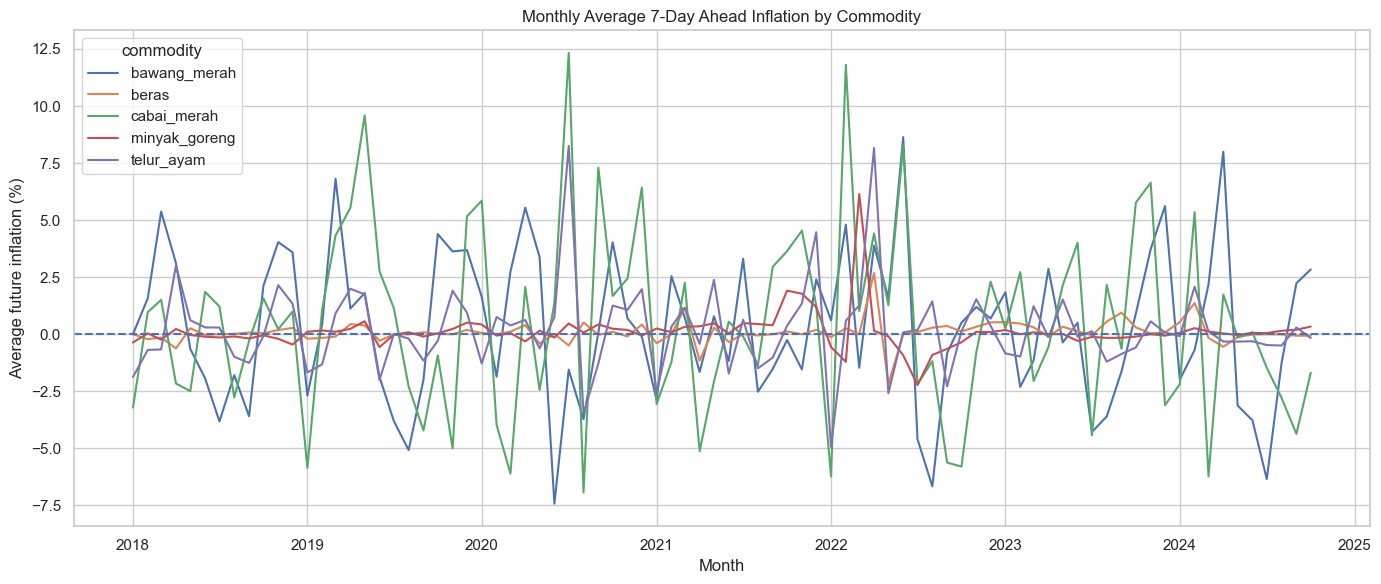

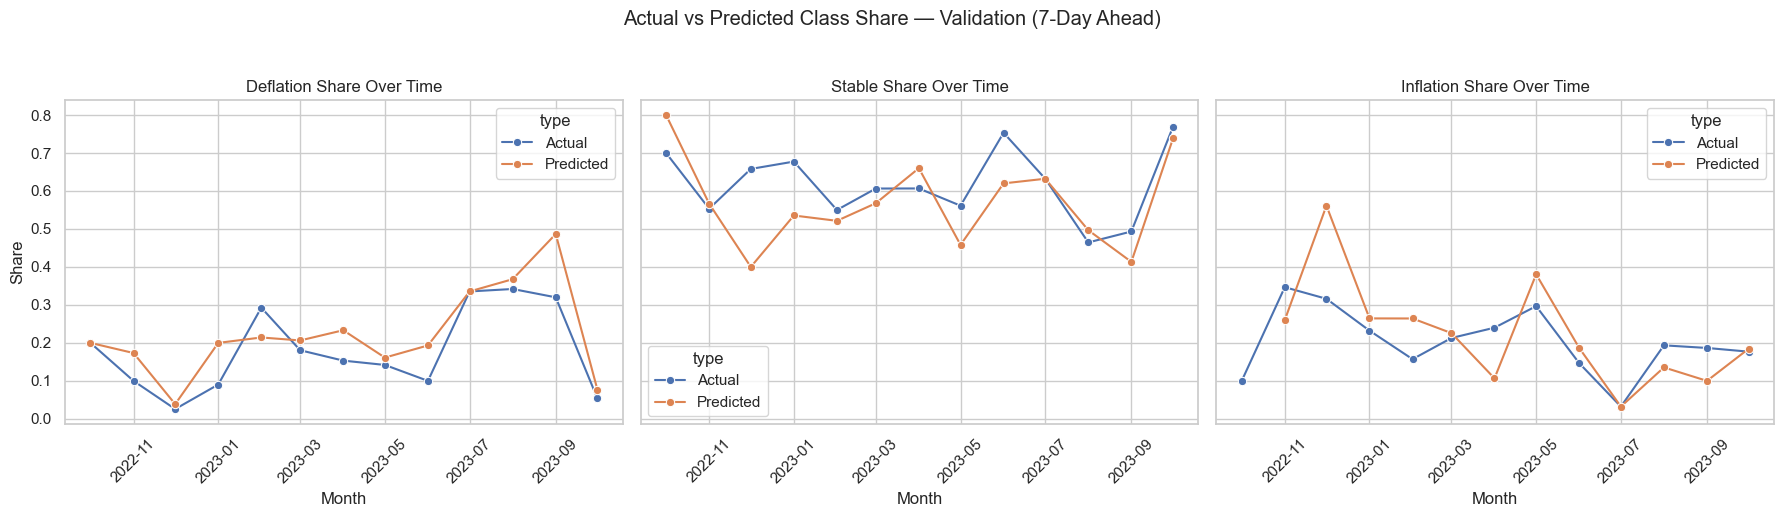

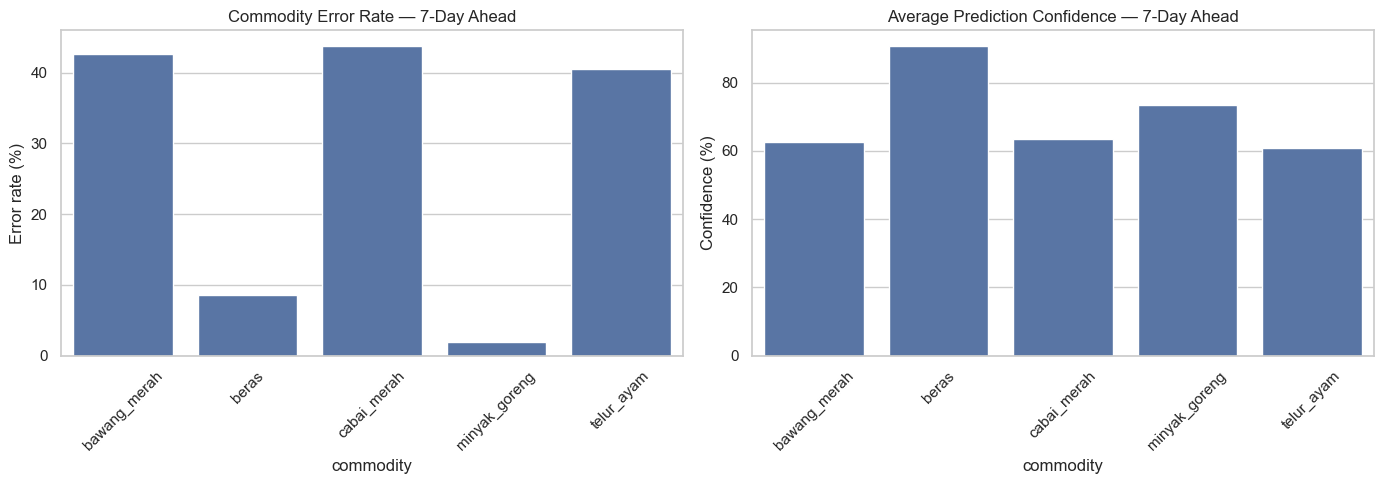

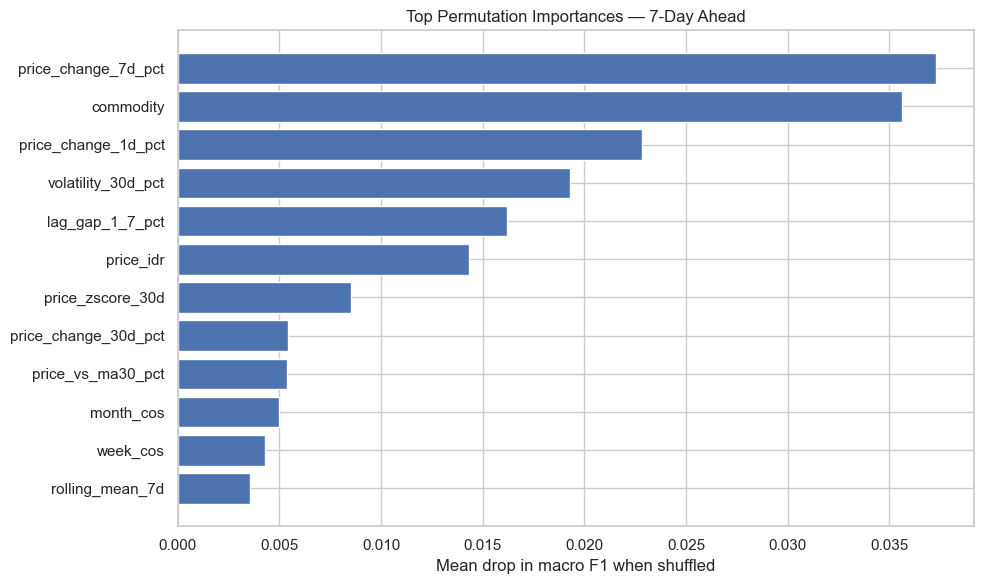

Generating monitoring views for 30-Day Ahead...


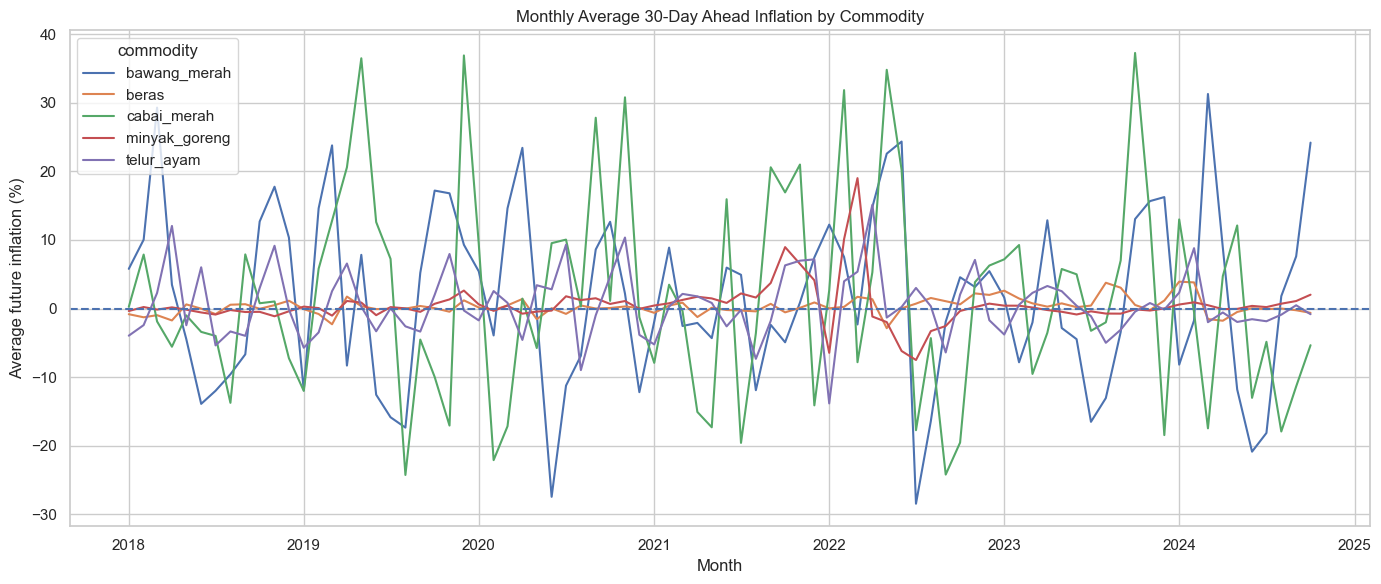

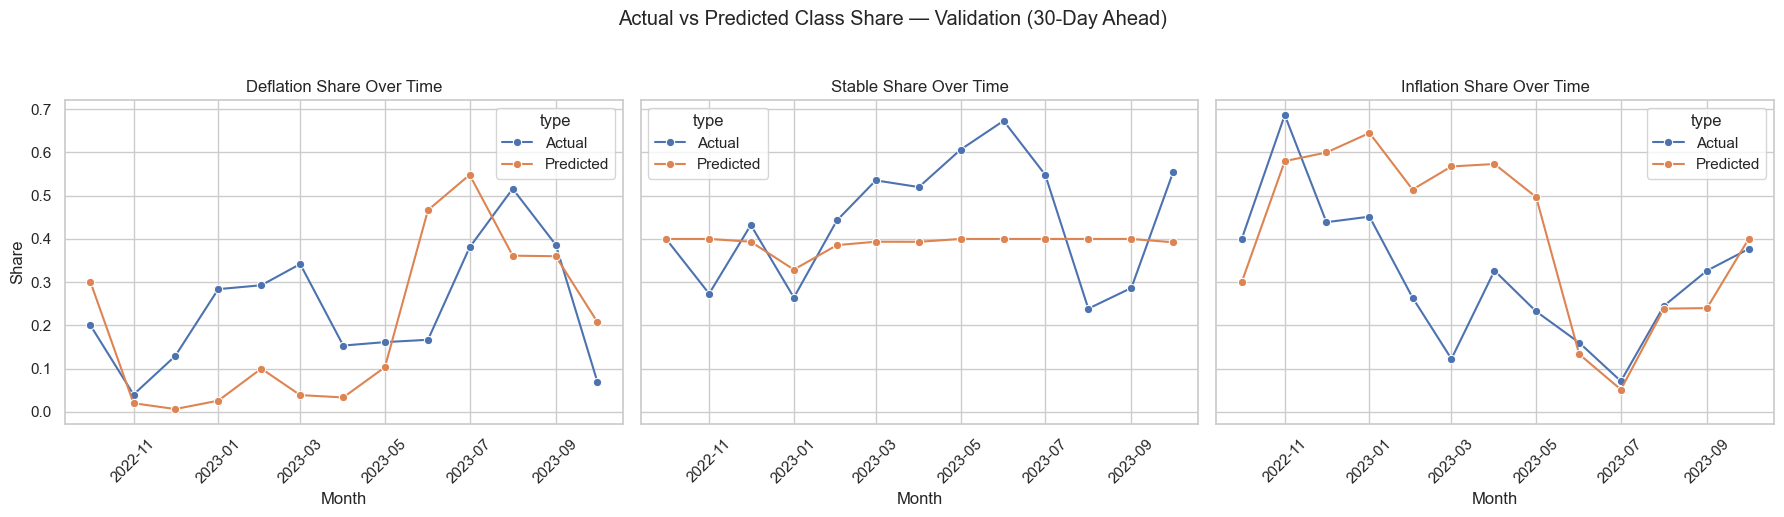

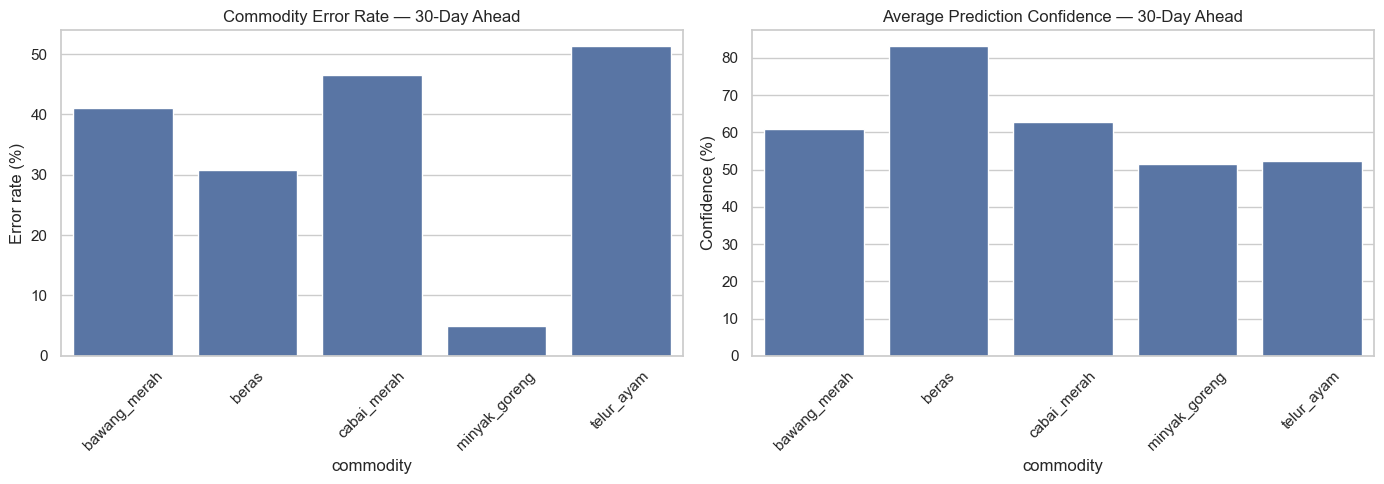

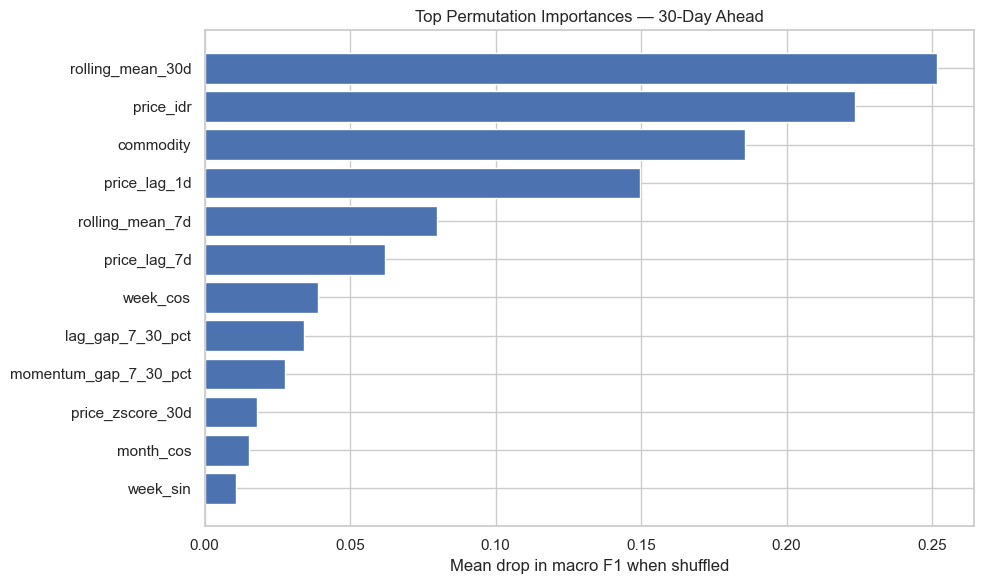

In [108]:
# run both horizon views

plot_monitoring_views("7d")
plot_monitoring_views("30d")

In [110]:
import joblib
from pathlib import Path

ARTIFACT_DIR = PROJECT_ROOT / "models"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(predict_model_7d, ARTIFACT_DIR / "model_7d.joblib")
joblib.dump(predict_model_30d, ARTIFACT_DIR / "model_30d_v2.joblib")
joblib.dump(feature_cols, ARTIFACT_DIR / "feature_cols.joblib")

df_fe.to_csv(PROJECT_ROOT / "data" / "processed" / "pihps_feature_engineered_v2.csv", index=False)

print("Saved dashboard artifacts to:", ARTIFACT_DIR)

Saved dashboard artifacts to: C:\Users\caran\Desktop\WORK\Projects\Misc\Mercatorie\models
